# Applying time series analysis for sales and demand forecasting


In this project, you will bridge the gap between theory and practical application by utilising time series analysis techniques to forecast sales and demand. Forecasting involves analysing historical sales data to accurately predict future sales trends and demand patterns.


Using time series analysis for sales and demand forecasting is crucial for data analysis in business because it can enhance decision-making by providing reliable sales and demand forecasts. This helps organisations reduce costs, maximise profits, and optimise resource allocation.

<br>

## **Business context**

The partner organisation is seeking to invest in developing a new service aimed at small to medium-sized independent publishers. This service is aimed at supporting publishers in using historical sales data to make data-driven decisions about their future investment in new publications. Their publisher customers are interested in being able to make more accurate predictions of the overall sales profile post-publication for better stock control and initial investment, but they are also interested in understanding the useful economic life span that a title may have.

The organisation is targeting small to medium-sized independent publishers as their research has shown that there is a strong demand for this insight, but businesses cannot invest in this infrastructure and would pay a premium to have access to quality-assured data and analysis in this area. Producing a new publication requires a significant upfront investment, and they would like to be able to more accurately identify books with strong long-term potential. More specifically, they are looking for titles with sales patterns that exhibit well-established seasonal patterns and positive trends that show potential great returns and to learn more about these types of publications.


<br>

## **Objective**

By the end of this project, you will have conducted a comprehensive analysis on select books from the given data, identifying key sales patterns that exhibit clear seasonal trends or other distinctive characteristics. These insights will serve as a data-driven foundation for optimising procurement, re-ordering, and stocking decisions, ensuring efficient inventory management.


In this Notebook, you will:

**Classical techniques:**
1. Perform decomposition on the data for both books. Determine what type of decomposition is suitable for each book, and comment on the components' characteristics.
2. Perform ACF and PACF on both books. Comment on the results and what they indicate.
3. Check for stationarity of the data for both books. Comment on the results and what they indicate.
4. Perform Auto ARIMA on both books.
5. Comment on the best model provided by Auto ARIMA for both books.
6. Find the residuals of the 'best' model for both books. Comment on the residuals.
7. Use the best model to predict the final 32 weeks of data. Plot the prediction along with the confidence intervals for both books.
8. Comment on how the prediction compares with the actual values.

**Machine learning and deep learning techniques**
1. Prepare the data to feed into the machine learning models.
2. Create the required pipeline for the XGBoost model.
3. Perform cross-validation.
4. Perform parameter tuning (including window_length) using grid search.
5. Identify the best models.
6. Use the best models to forecast the **final 32 weeks** of sales data for both books.
7. Plot the original data along with the predictions.
8. Display the MAE and MAPE.
9. Create an LSTM model for both books.
10. Apply KerasTuner, and perform hyperparameter tuning using the training data, for both books.
11. Use the best model to predict the **final 32 weeks** of data for both books.
12. Plot the original data along with the predictions.
13. Display the MAE and MAPE.

**Hybrid model**
1. Apply a hybrid model of SARIMA and LSTM in sequential combination wherein the residuals from SARIMA will be forecasted using LSTM. The final prediction will be the sum of the predictions from SARIMA and LSTM. The LSTM will be trained on the residuals obtained during the training of the SARIMA model. **The forecast horizon will be the final 32 weeks**. Plot the results. Display the MAE and MAPE, and comment on the results.
2. Apply a hybrid model of SARIMA and LSTM in parallel combination wherein the predictions from SARIMA and the predictions from LSTM will be combined in the form of a weighted average. The final prediction will be the weighted sum of the predictions from SARIMA and LSTM. Both the SARIMA and the LSTM will be trained separately on the complete training set. **The forecast horizon will be the final 32 weeks**. Plot the results. Display the MAE and MAPE, and comment on the results.
3. Modify the weightage in the parallel combination model to get different results. Find the weightage giving the best results, and comment on those results.

**Monthly prediction**
1. Instead of a weekly prediction, perform a monthly prediction. Aggregate the weekly sales data to monthly sales data for both books.
2. Train the XGBoost model on this data. Forecast using the trained model. The forecast horizon is 8 months. Plot the results, and calculate the MAE and MAPE.
3. Train the SARIMA model (using Auto ARIMA) on this data. Forecast using the trained model. The forecast horizon is 8 months. Plot the results, and calculate the MAE and MAPE.
4. Compare and contrast the monthly predictions of both books against the weekly predictions. Comment on which one is more accurate or if they are the same.

# Importing Packages & Data

In [ ]:
!pip install sktime "numpy<2.0" pmdarima tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 16.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatibl

In [ ]:
!pip install keras-tuner --upgrade

  Using cached keras_tuner-1.4.8-py3-none-any.whl.metadata (5.6 kB)
  Using cached kt_legacy-1.0.5-py3-none-any.whl.metadata (221 bytes)
Using cached keras_tuner-1.4.8-py3-none-any.whl (129 kB)
Using cached kt_legacy-1.0.5-py3-none-any.whl (9.6 kB)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
import pmdarima as pm
import tensorflow as tf
import sktime
from sktime.forecasting.arima import AutoARIMA
from datetime import datetime, timedelta
from matplotlib.patches import Rectangle
import matplotlib.animation as animation
from matplotlib import animation
from matplotlib import rc
import statsmodels.graphics.api as smgraphics # gives access to all plotting functions in statsmodels.
from statsmodels.tsa.stattools import adfuller as adf
from statsmodels.tsa.seasonal import STL
from scipy.stats import boxcox
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from pmdarima.arima import auto_arima
from statsmodels.tsa.stattools import acf
from sklearn.metrics import mean_squared_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

plt.rcParams["figure.figsize"] = (10, 5)

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

import warnings

# Suppress all warnings.
warnings.filterwarnings("ignore")

print(" All libraries imported successfully!")


 All libraries imported successfully!


In [ ]:
import gdown
import os

data_folder_url = "https://drive.google.com/drive/folders/1o8fZaaECKUnLYJAK4pqR4e3WyOFYhc_o"

# Create a directory to store the downloaded files.
# Using 'data_files' as the folder name.
download_dir = 'data_files'
if not os.path.exists(download_dir):
    os.makedirs(download_dir)

# Download the contents of the Google Drive folder using gdown.
# This will download all files from the specified folder into the 'data_files' directory.
print(f"Downloading files from {data_folder_url} into '{download_dir}' directory...")
gdown.download_folder(url=data_folder_url, output=download_dir, quiet=True)
print("Download complete.")


Download complete.


In [ ]:
# Now, read the Excel files from the local downloaded directory.
# Ensure the filenames match those in the folder.
data_dictionary_UK = pd.read_excel(os.path.join(download_dir, 'UK Weekly Trended Timeline from 200101_202429.xlsx'), sheet_name=None)

In [ ]:
print(data_dictionary_UK.keys())

dict_keys(['F Adult Fiction', 'S Adult Non-Fiction Specialist', 'T Adult Non-Fiction Trade', "Y Children's, YA & Educational"])


In [ ]:
data_dictionary_ISBN = pd.read_excel(os.path.join(download_dir, 'ISBN List.xlsx'), sheet_name=None)

In [ ]:
print(data_dictionary_ISBN.keys())

dict_keys(['F - Adult Fiction', 'S Adult Non-Fiction Specialist', 'T Adult Non-Fiction Trade', "Y Children's, YA & Educational"])


In [ ]:
# Combine all sheets in data_dictionary_UK  into a single DataFrame with an extra column to identify the sheet
df_UK_weekly = pd.concat(
    [df.assign(Category=sheet_name) for sheet_name, df in data_dictionary_UK.items()],
    ignore_index=True
)


In [ ]:
df_UK_weekly.head()

,ISBN,Title,Author,Interval,End Date,Volume,Value,ASP,RRP,Binding,Imprint,Publisher Group,Product Class,Category
0,9780002261821,One For My Baby,"Parsons, Tony",200513,2005-04-02,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
1,9780002261821,One For My Baby,"Parsons, Tony",200503,2005-01-22,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2,9780002261821,One For My Baby,"Parsons, Tony",200422,2004-05-29,1,11.19,11.19,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
3,9780002261821,One For My Baby,"Parsons, Tony",200415,2004-04-10,2,27.18,13.59,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
4,9780002261821,One For My Baby,"Parsons, Tony",200404,2004-01-24,2,22.48,11.24,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction


In [ ]:
# Combine all sheets in data_dictionary_ISBN  into a single DataFrame with an extra column to identify the sheet
df_ISBN = pd.concat(
    [df.assign(Category=sheet_name) for sheet_name, df in data_dictionary_ISBN.items()],
    ignore_index=True
)

In [ ]:
df_ISBN.head()

,ISBN,Title,Author,Imprint,Publisher Group,RRP,Binding,Publication Date,Product Class,Country of Publication,Category
0,9780330375252,Bridget Jones's Diary (Film Tie-in),"Fielding, Helen",Picador,Pan Macmillan Grp,8.99,Paperback,2001-03-23,F1.1 General & Literary Fiction,United Kingdom,F - Adult Fiction
1,9780140276336,White Teeth,"Smith, Zadie",Penguin Books Ltd,Penguin Grp,9.99,Paperback,2001-01-25,F1.1 General & Literary Fiction,United Kingdom,F - Adult Fiction
2,9780006512134,Man and Boy,"Parsons, Tony",HarperCollins Publishers,HarperCollins Grp,8.99,Paperback,2000-03-06,F1.1 General & Literary Fiction,United Kingdom,F - Adult Fiction
3,9780099280255,"Brethren,The","Grisham, John",Arrow Books,Random House Grp,6.99,Paperback,2000-12-27,"F2.1 Crime, Thriller & Adventure",United Kingdom,F - Adult Fiction
4,9780552998727,Marrying The Mistress:an irresistible and grip...,"Trollope, Joanna",Black Swan,Transworld Grp,10.99,Paperback,2001-02-01,F1.1 General & Literary Fiction,United Kingdom,F - Adult Fiction


# Conducting Initial Data Investigation

Note that the data provided is weekly data.

If no sales happened in a particular week, there will be no data representation for that week. This means that the data is not at fixed intervals.

As a result, resample the data and fill in missing values with 0, such that even weeks with 0 sales is represented.

Convert the ISBNs to a string value.

Convert date to datetime object. (Recall that setting the date as the index has several advantages for time series handling.)

In [ ]:
#replace spaces with underscores across all column names
df_UK_weekly.columns = df_UK_weekly.columns.str.replace(' ', '_')
df_ISBN.columns = df_ISBN.columns.str.replace(' ', '_')

In [ ]:
# Convert ISBN to string
df_UK_weekly['ISBN'] = df_UK_weekly['ISBN'].astype(str)

In [ ]:
df_ISBN['ISBN'] = df_ISBN['ISBN'].astype(str)

In [ ]:
# Ensure End Date is datetime and set as index
df_UK_weekly['End_Date'] = pd.to_datetime(df_UK_weekly['End_Date'])

In [ ]:
# Set 'End_Date' as the index
df_UK_weekly.set_index('End_Date', inplace=True)

In [ ]:
df_UK_weekly.head()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2005-04-02,9780002261821,One For My Baby,"Parsons, Tony",200513,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2005-01-22,9780002261821,One For My Baby,"Parsons, Tony",200503,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2004-05-29,9780002261821,One For My Baby,"Parsons, Tony",200422,1,11.19,11.19,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2004-04-10,9780002261821,One For My Baby,"Parsons, Tony",200415,2,27.18,13.59,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2004-01-24,9780002261821,One For My Baby,"Parsons, Tony",200404,2,22.48,11.24,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction


In [ ]:
df_UK_weekly.shape

(227224, 13)

In [ ]:
# Sort the dataframe chronologically by the End_Date index
df_UK_weekly.sort_index(inplace=True)


In [ ]:
df_UK_weekly.head()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2001-01-06,9781841461502,KS2 English Study Book - Ages 7-11,CGP Books,200101,700,2370.97,3.3871,6.50,Paperback,Coordination Group Publications Ltd (CGP),Coordination Group Publications,Y5.1 School Textbooks & Study Guides: Literatu...,"Y Children's, YA & Educational"
2001-01-06,9780130125071,Java How to Program,"Deitel, Harvey M. & Deitel, Paul J.",200101,72,2267.40,31.4917,38.09,Hardback,Prentice-Hall,Pearson Education: Prof Grp,S10.2 Computing: Professional & Programming,S Adult Non-Fiction Specialist
2001-01-06,9780563384311,Delia's How To Cook: Book Two,"Smith, Delia",200101,1878,21032.36,11.1993,20.00,Hardback,BBC Books (Random House),Random House Grp,T16.0 Food & Drink: General,T Adult Non-Fiction Trade
2001-01-06,9780340704622,Business Studies,"Marcouse, Ian & Martin, Barry & Surridge, Malc...",200101,90,1698.07,18.8674,NaN,Paperback,Hodder & Stoughton Ltd,Hodder & Stoughton Grp,"S4.0T Business, Accounting & Vocational: Textb...",S Adult Non-Fiction Specialist
2001-01-06,9781841462301,KS3 Science Revision Guide – Higher (includes ...,CGP Books,200101,463,1618.41,3.4955,6.50,Hardback,Coordination Group Publications Ltd (CGP),Coordination Group Publications,"Y5.3 School Textbooks & Study Guides: Maths, S...","Y Children's, YA & Educational"


In [ ]:
df_UK_weekly.tail()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2024-07-20,9780099771517,Memoirs of a Geisha,"Golden, Arthur",202429,43,409.64,9.5265,9.99,Paperback,Vintage,Random House Grp,F1.1 General & Literary Fiction,F Adult Fiction
2024-07-20,9780241003008,"Very Hungry Caterpillar, The","Carle, Eric",202429,2574,11507.46,4.4707,7.99,Hardback,Puffin Books,Penguin Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"
2024-07-20,9780006647553,Mog’s Bad Thing,"Kerr, Judith",202429,11,86.89,7.8991,7.99,Paperback,HarperCollins Publishers,HarperCollins Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"
2024-07-20,9780006531203,In the Heart of the Sea,"Philbrick, Nathaniel",202429,3,32.97,10.9900,10.99,Paperback,HarperCollins Publishers,HarperCollins Grp,T5.3 History: Specific Subjects,T Adult Non-Fiction Trade
2024-07-20,9780006550433,"Bonesetter’s Daughter, The","Tan, Amy",202429,1,9.99,9.9900,9.99,Paperback,Flamingo,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction


In [ ]:
df_UK_weekly_g = (
    df_UK_weekly
    .groupby('ISBN')
    .resample('W')
    .sum()
    .fillna(0)
)

# Remove duplicate index level before reset_index
df_UK_weekly_g.index = df_UK_weekly_g.index.droplevel(0)  # drop 'ISBN' from index
df_UK_weekly_g = df_UK_weekly_g.reset_index()


In [ ]:
df_UK_weekly_g.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382871 entries, 0 to 382870
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   End_Date         382871 non-null  datetime64[ns]
 1   ISBN             382871 non-null  object        
 2   Title            382871 non-null  object        
 3   Author           382871 non-null  object        
 4   Interval         382871 non-null  int64         
 5   Volume           382871 non-null  int64         
 6   Value            382871 non-null  float64       
 7   ASP              382871 non-null  float64       
 8   RRP              382871 non-null  float64       
 9   Binding          382871 non-null  object        
 10  Imprint          382871 non-null  object        
 11  Publisher_Group  382871 non-null  object        
 12  Product_Class    382871 non-null  object        
 13  Category         382871 non-null  object        
dtypes: datetime64[ns](1)

In [ ]:
df_UK_weekly_g.head()

,End_Date,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
0,2001-01-07,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200101,522,2544.07,4.8737,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"
1,2001-01-14,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200102,379,1842.21,4.8607,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"
2,2001-01-21,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200103,393,1921.19,4.8885,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"
3,2001-01-28,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200104,369,1785.31,4.8382,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"
4,2001-02-04,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200105,423,2060.07,4.8701,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"


In [ ]:
df_UK_weekly_g.tail()

,End_Date,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
382866,2008-11-23,0,0,0,0,0,0.00,0.00,0.00,0,0,0,0,0
382867,2008-11-30,0,0,0,0,0,0.00,0.00,0.00,0,0,0,0,0
382868,2008-12-07,9781903840122,"Wicked Book of Txt Tlk, The",0,200849,1,0.40,0.40,1.99,Paperback,Buster Books,Michael O'Mara Grp,Y4.1 Children's General Interest & Leisure,"Y Children's, YA & Educational"
382869,2008-12-14,9781903840122,"Wicked Book of Txt Tlk, The",0,200850,4,1.60,0.40,1.99,Paperback,Buster Books,Michael O'Mara Grp,Y4.1 Children's General Interest & Leisure,"Y Children's, YA & Educational"
382870,2008-12-21,9781903840122,"Wicked Book of Txt Tlk, The",0,200851,2,2.38,1.19,1.99,Paperback,Buster Books,Michael O'Mara Grp,Y4.1 Children's General Interest & Leisure,"Y Children's, YA & Educational"


In [ ]:
# Set End_Date as index
df_UK_weekly_g.set_index('End_Date', inplace=True)

# Sort the dataframe chronologically
df_UK_weekly_g.sort_index(inplace=True)


In [ ]:
df_UK_weekly_g.head()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2001-01-07,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200101,522,2544.07,4.8737,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"
2001-01-07,9780003224764,Psychology for AS-level,"Cardwell, Mike & Clark, Liz & Meldrum, Claire",200101,40,482.56,12.0640,12.99,Paperback,Collins Educational,HarperCollins Grp,S2.2T Psychology: Textbooks & Study Guides,S Adult Non-Fiction Specialist
2001-01-07,9780718144395,"Return of the Naked Chef, The","Oliver, Jamie",200101,5742,83782.37,14.5911,20.00,Hardback,Michael Joseph,Penguin Grp,T16.0 Food & Drink: General,T Adult Non-Fiction Trade
2001-01-07,9780552998727,Marrying the Mistress,"Trollope, Joanna",200101,573,4005.18,6.9898,10.99,Paperback,Black Swan,Transworld Grp,F1.1 General & Literary Fiction,F Adult Fiction
2001-01-07,9780115519772,Highway Code,0,200101,6185,9168.94,1.4824,1.49,Paperback,Stationery Office Books,The Stationery Office Grp,T12.2 Driving & The Highway Code,T Adult Non-Fiction Trade


In [ ]:
df_UK_weekly_g.tail()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2024-07-21,9780744523232,We're Going on a Bear Hunt,"Rosen, Michael",202429,1556,6546.74,4.2074,7.99,Paperback,Walker Books Ltd,Walker Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"
2024-07-21,9780552145060,Journey,"Steel, Danielle",202429,2,18.38,9.1900,9.99,Paperback,Corgi Books,Transworld Grp,F1.1 General & Literary Fiction,F Adult Fiction
2024-07-21,9780006647553,Mog’s Bad Thing,"Kerr, Judith",202429,11,86.89,7.8991,7.99,Paperback,HarperCollins Publishers,HarperCollins Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"
2024-07-21,9780440864141,Jacqueline Wilson Double Decker,"Wilson, Jacqueline",202429,5,38.91,7.7820,7.99,Paperback,Yearling (imprint of Random House Children's B...,Random House Childrens Books Grp,Y2.1 Children's Fiction,"Y Children's, YA & Educational"
2024-07-21,9780752844299,Arthur: The Seeing Stone,"Crossley-Holland, Kevin",202429,6,39.49,6.5817,6.99,Paperback,Orion (an Imprint of The Orion Publishing Grou...,Orion Grp,Y2.2 Young Adult Fiction,"Y Children's, YA & Educational"


Filter out the ISBNs (from all four tabs) wherein sales data exists beyond 2024-07-01.

Show all the ISBNs that satisfy this criterion. Capture this in your report.

In [ ]:
# Filter df_UK_weekly for records with sales data beyond 2024-07-01
df_UK_weekly_filtered = df_UK_weekly_g[df_UK_weekly_g.index > '2024-07-01']

In [ ]:
# Get the list of ISBNs that meet the condition
isbn_filtered = df_UK_weekly_filtered['ISBN'].unique()

In [ ]:
len(isbn_filtered )

62

In [ ]:
# Show the filtered ISBNs
print(isbn_filtered)

['9780099244721' 0 '9780140276336' '9780099422587' '9780719559792'
 '9781841461502' '9780006514213' '9780261103252' '9780140275421'
 '9780349113609' '9780722532935' '9780752844299' '9780340766057'
 '9780552998482' '9780552998444' '9780552997348' '9780349112763'
 '9780552145954' '9781841462509' '9780552997034' '9780593048153'
 '9780091867775' '9780099285823' '9780440864554' '9780552998000'
 '9781841150437' '9780552998727' '9780140285215' '9780006647553'
 '9780006514091' '9780099771517' '9780749397548' '9781841460307'
 '9780140259506' '9780140276619' '9780140294231' '9780241003008'
 '9780747268161' '9780340696767' '9780749395698' '9780099428558'
 '9780744523232' '9780006531203' '9781841462400' '9781841462301'
 '9780091816971' '9780140281293' '9780006512134' '9781841460406'
 '9780440864141' '9780140295962' '9780099286578' '9780349114033'
 '9780224060875' '9780340786055' '9780330355667' '9780007101887'
 '9780552145060' '9780752846576' '9780006550433' '9780099286387'
 '9780552145053']


Plot the data of all the ISBNs from the previous step by placing them in a loop.

In [ ]:
# Create a plot grid (e.g., 8x8 grid for 64 slots, leaving some empty space for 61 ISBNs)
num_plots = len(isbn_filtered)
rows = (num_plots // 6) + (1 if num_plots % 6 != 0 else 0)  # Calculate number of rows needed
cols = 6  # 8 plots per row


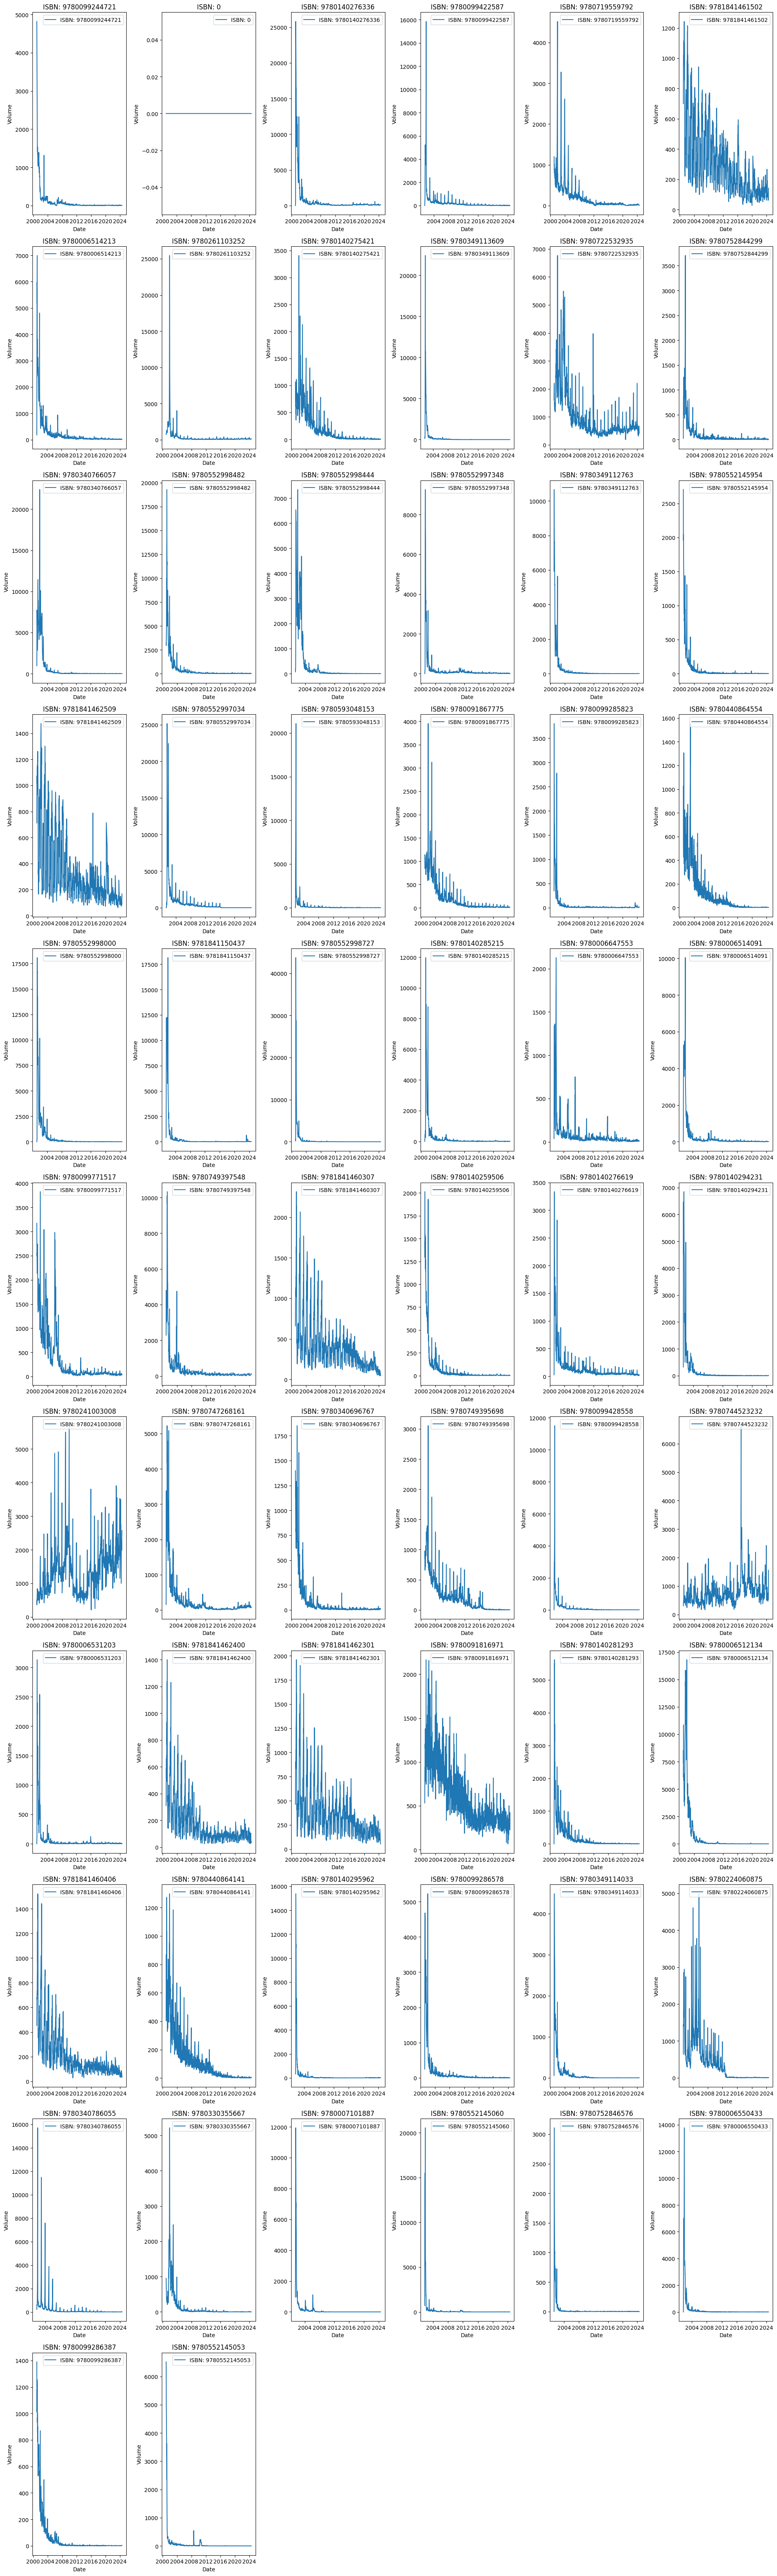

In [ ]:
# Create the figure and axes for subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 6 * rows))

# Flatten the axes array for easy indexing
axes = axes.flatten()

# Loop through each ISBN and plot the data from the original df_UK_weekly dataframe
for idx, isbn in enumerate(isbn_filtered):
    # Filter the original df_UK_weekly to get data for the current ISBN
    df_UK_weekly_isbn = df_UK_weekly_g[df_UK_weekly_g['ISBN'] == isbn]

    # Plot the data
    axes[idx].plot(df_UK_weekly_isbn.index, df_UK_weekly_isbn['Volume'], label=f'ISBN: {isbn}')
    axes[idx].set_title(f'ISBN: {isbn}')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Volume')
    axes[idx].legend()

# Remove unused subplots if there are any
for idx in range(num_plots, len(axes)):
    fig.delaxes(axes[idx])

# Adjust layout for better spacing
plt.tight_layout()

### Investigate these plots to understand the general sales patterns, and comment on the general patterns visible in the data.

* Across most titles, sales follow a similar lifecycle pattern: a strong initial peak after release, followed by a sharp decline and eventual stabilisation at lower levels.
* Across most titles, sales follow a similar lifecycle pattern: a strong initial peak after release, followed by a sharp decline and eventual stabilisation at lower levels.
* Comparing years 1–12 with years 12–24, the overall structural pattern does not drastically change. The main difference is that volatility tends to reduce over time.
* In the earlier period, sales are higher and more variable due to active promotion, wider retail visibility, and novelty effects.
* In the later period, sales generally stabilise at lower levels, with occasional seasonal spikes for enduring or curriculum-linked titles.
* This suggests that while absolute sales volumes decline over time, the underlying demand dynamics—initial surge followed by gradual decay and stabilisation—remain consistent across the product lifecycle.



Select two books from the list (The Alchemist and The Very Hungry Caterpillar) for further analysis.

Focus on the period >2012-01-01.

Filter the sales data for both these books to retain the date range >2012-01-01, until the final datapoint.  

In [ ]:
df_UK_weekly_g.head()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2001-01-07,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200101,522,2544.07,4.8737,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning,"Y Children's, YA & Educational"
2001-01-07,9780003224764,Psychology for AS-level,"Cardwell, Mike & Clark, Liz & Meldrum, Claire",200101,40,482.56,12.0640,12.99,Paperback,Collins Educational,HarperCollins Grp,S2.2T Psychology: Textbooks & Study Guides,S Adult Non-Fiction Specialist
2001-01-07,9780718144395,"Return of the Naked Chef, The","Oliver, Jamie",200101,5742,83782.37,14.5911,20.00,Hardback,Michael Joseph,Penguin Grp,T16.0 Food & Drink: General,T Adult Non-Fiction Trade
2001-01-07,9780552998727,Marrying the Mistress,"Trollope, Joanna",200101,573,4005.18,6.9898,10.99,Paperback,Black Swan,Transworld Grp,F1.1 General & Literary Fiction,F Adult Fiction
2001-01-07,9780115519772,Highway Code,0,200101,6185,9168.94,1.4824,1.49,Paperback,Stationery Office Books,The Stationery Office Grp,T12.2 Driving & The Highway Code,T Adult Non-Fiction Trade


In [ ]:
alchemist_isbns = df_ISBN[df_ISBN['Title'].str.contains('alchemist', case=False, na=False)]['ISBN'].astype(str).unique()
caterpillar_isbns = df_ISBN[df_ISBN['Title'].str.contains('caterpillar', case=False, na=False)]['ISBN'].astype(str).unique()


In [ ]:
print("The Alchemist ISBNs:")
print(alchemist_isbns)

print("\n The Very Hungry Caterpillar ISBNs:")
print(caterpillar_isbns)


The Alchemist ISBNs:
['9780722532935']

 The Very Hungry Caterpillar ISBNs:
['9780241003008' '9780140500875']


In [ ]:
# Apply the date filter to df_UK_weekly
df_UK_weekly_post2012 = df_UK_weekly_g[df_UK_weekly_g.index > '2012-01-01']

# For The Very Hungry Caterpillar ISBNs
for isbn in caterpillar_isbns:
    volume_caterpillar = df_UK_weekly_post2012[df_UK_weekly_post2012['ISBN'] == isbn]['Volume'].sum()
    print(f"Volume for ISBN {isbn} (The Very Hungry Caterpillar) after 2012-01-01: {volume_caterpillar}")

# For The Alchemist ISBNs
for isbn in alchemist_isbns:
    volume_alchemist = df_UK_weekly_post2012[df_UK_weekly_post2012['ISBN'] == isbn]['Volume'].sum()
    print(f"Volume for ISBN {isbn} (The Alchemist) after 2012-01-01: {volume_alchemist}")


Volume for ISBN 9780241003008 (The Very Hungry Caterpillar) after 2012-01-01: 883534
Volume for ISBN 9780140500875 (The Very Hungry Caterpillar) after 2012-01-01: 2
Volume for ISBN 9780722532935 (The Alchemist) after 2012-01-01: 345907


We will be analysing:

Volume for ISBN 9780241003008 (The Very Hungry Caterpillar) after 2012-01-01: 883534

Volume for ISBN 9780722532935 (The Alchemist) after 2012-01-01: 345907

In [ ]:
# Directly filter df_UK_weekly_post2012 for the two ISBNs
df_UK_weekly_post2012 = df_UK_weekly_post2012[df_UK_weekly_post2012['ISBN'].isin(['9780241003008', '9780722532935'])]


In [ ]:
df_UK_weekly_post2012.head()

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2012-01-08,9780241003008,"Very Hungry Caterpillar, The","Carle, Eric",201201,512,2522.13,4.9260,7.99,Hardback,Puffin Books,Penguin Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"
2012-01-08,9780722532935,"Alchemist, The","Coelho, Paulo",201201,518,3601.76,6.9532,9.99,Paperback,Thorsons,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2012-01-15,9780241003008,"Very Hungry Caterpillar, The","Carle, Eric",201202,519,2473.31,4.7655,7.99,Hardback,Puffin Books,Penguin Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"
2012-01-15,9780722532935,"Alchemist, The","Coelho, Paulo",201202,533,3610.12,6.7732,9.99,Paperback,Thorsons,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2012-01-22,9780722532935,"Alchemist, The","Coelho, Paulo",201203,475,3105.62,6.5381,9.99,Paperback,Thorsons,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction


In [ ]:
df_UK_weekly_post2012.shape

(1256, 13)

In [ ]:
df_UK_weekly_post2012['Title'].unique()

array(['Very Hungry Caterpillar, The', 'Alchemist, The'], dtype=object)

In [ ]:
# sorting the titles to read 'The Alchemist' and 'The Very Hungry Caterpillar'
df_UK_weekly_post2012['Title'] = df_UK_weekly_post2012['Title'].str.replace(r'^(.*), The$', r'The \1', regex=True)


In [ ]:
df_UK_weekly_post2012['Title'].unique()

array(['The Very Hungry Caterpillar', 'The Alchemist'], dtype=object)

In [ ]:
df_UK_weekly_post2012['Volume'].isna().sum()

0

# Classical Techniques

In [ ]:
#Get weekly book data for given ISBN
def get_book_data(isbn,period = "weekly"):
  book_data = df_UK_weekly_post2012[df_UK_weekly_post2012['ISBN'] == isbn].copy()
  if period == "monthly":
      book_data = book_data.asfreq('M').fillna(0)
  else:  # weekly
      book_data = book_data.asfreq('W').fillna(0)

  return book_data

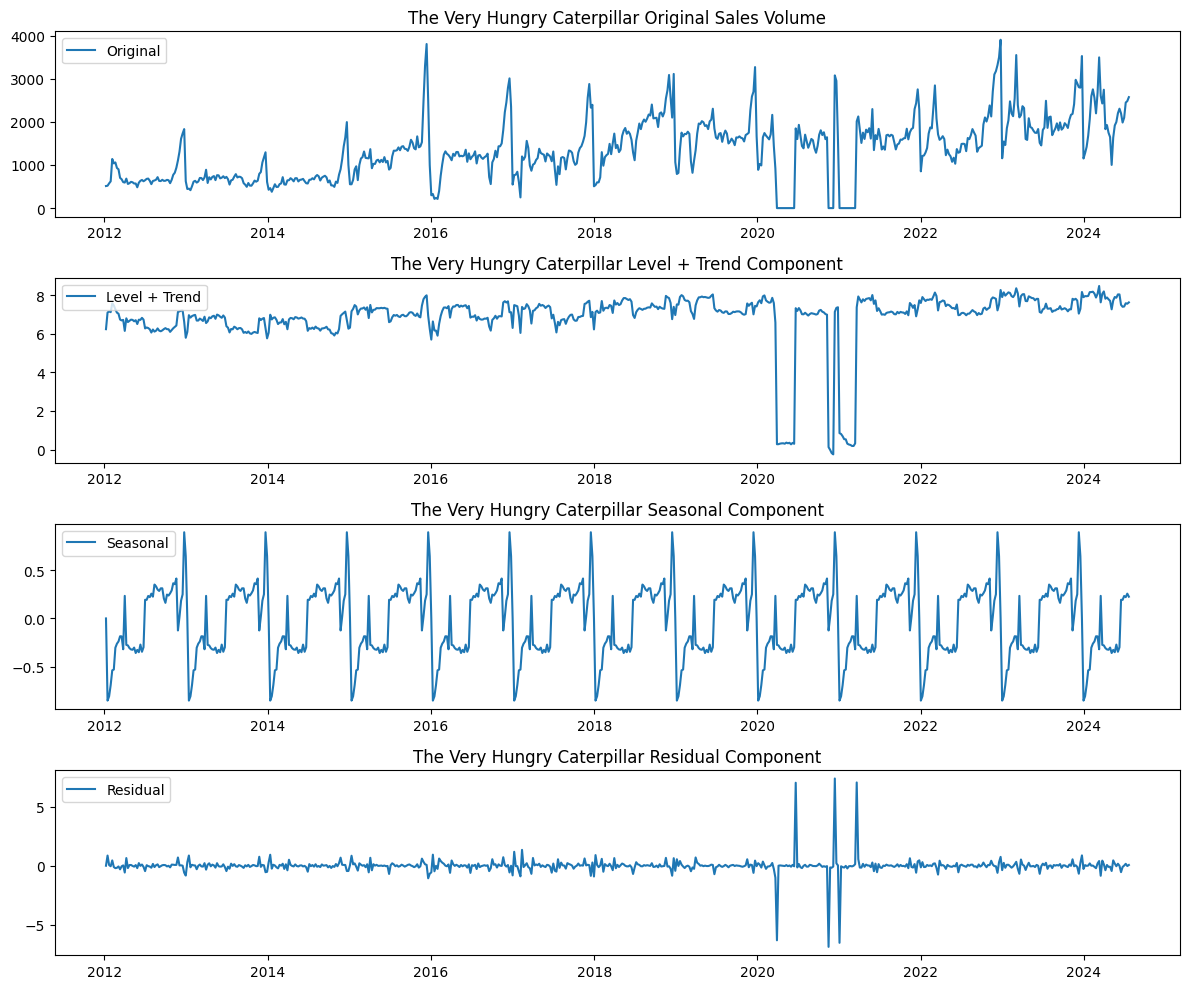

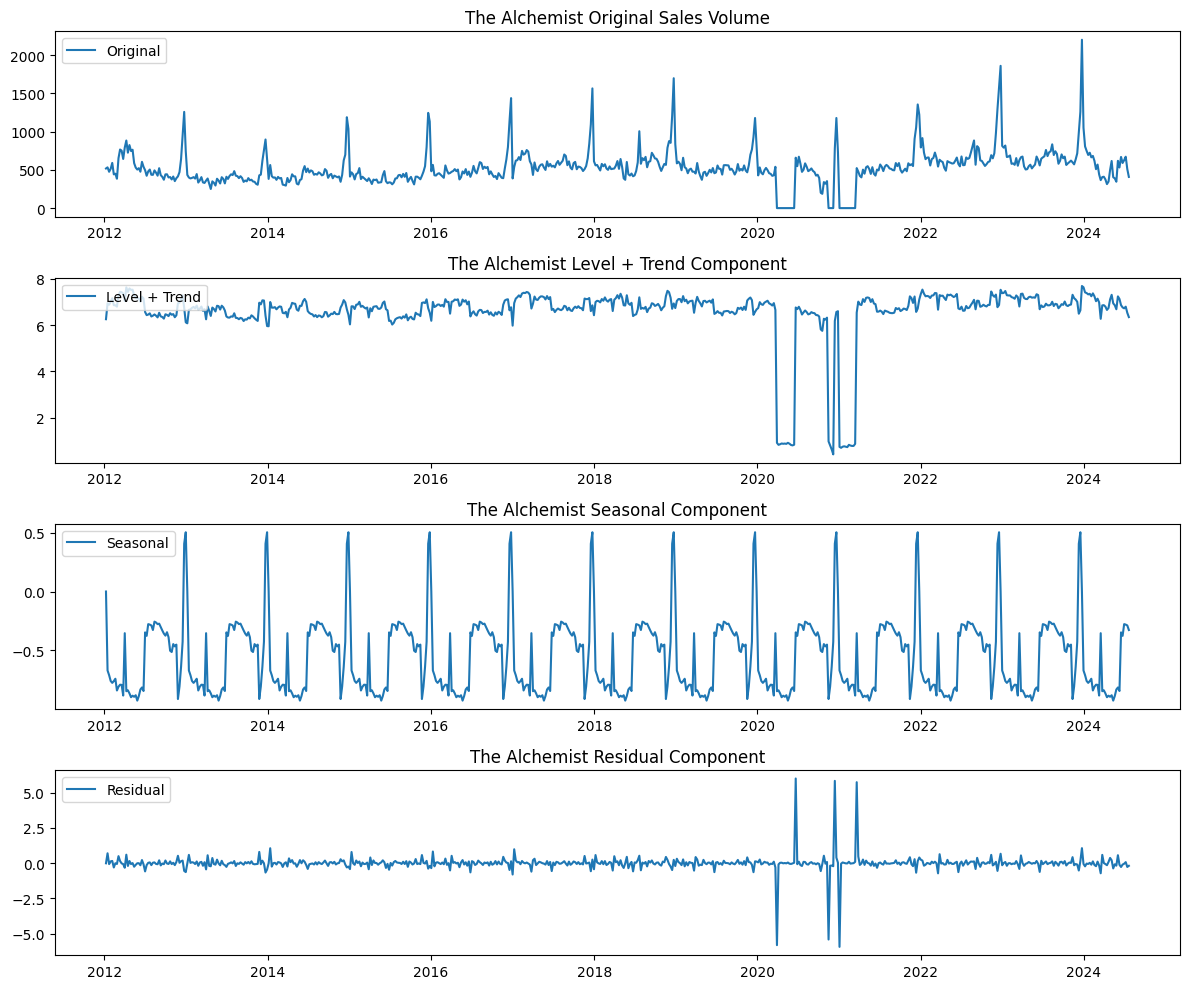

In [ ]:
#Perform decomposition on the data for both books
#12 years data = 12852 = 624 weeks, since its book sales very like patterns are yearly seasonality (52 weeks), possible christmas spikes, possible back-to-school spikes
#try addictive first and then compare with multiplicative
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

# List of ISBNs to plot
isbns_to_plot = ['9780241003008', '9780722532935']

# Loop through the ISBNs and plot
for isbn in isbns_to_plot:
    book_data_current = get_book_data(isbn)

    # Get the unique title(s) for the ISBN
    title = book_data_current['Title'].unique()[0]
    ts_book = book_data_current['Volume'].values.astype(float)
    ts_book_log = np.log(book_data_current['Volume']+1).values.astype(float)

    # Define the model. Using additive seasonal component to handle zero values.
    model = ETSModel(ts_book_log,
                 error='add',
                 trend='add',
                 damped_trend=None,
                 seasonal='add',
                 seasonal_periods=52)
    fit = model.fit(maxiter=10000)

    # Plot the various components after decomposition of the time series.
    plt.figure(figsize=(12, 10))
    plt.subplot(411)
    plt.plot(book_data_current.index, ts_book, label='Original')
    plt.legend(loc='upper left')
    plt.title(title + ' Original Sales Volume')

    plt.subplot(412)
    plt.plot(book_data_current.index, fit.level, label='Level + Trend')
    plt.legend(loc='upper left')
    plt.title(title + ' Level + Trend Component')

    plt.subplot(413)
    plt.plot(book_data_current.index, fit.season, label='Seasonal')
    plt.legend(loc='upper left')
    plt.title(title + ' Seasonal Component')

    plt.subplot(414)
    plt.plot(book_data_current.index, fit.resid, label='Residual')
    plt.legend(loc='upper left')
    plt.title(title + ' Residual Component')

    plt.tight_layout()
    plt.show()

###Determine what type of decomposition is suitable for each book and comment on the component's characteristics         |

###The Alchemist : Observations from Original Series
- Clear upward trend
- Seasonal peaks grow slightly as level increases
- Seasonal amplitude appears proportional to overall sales level
- COVID drop createse extreme proportional change.

This suggests: Seasonal variation increases with the level of the series.

**Suitable Decomposition: Multiplicative (or log-additive)**

Since we log-transformed the series before decomposition, we effectively performed a multiplicative decomposition

###The Very Hungry Caterpillar : Observations from Original Series
- Also has upward trend.
- Seasonal peaks increase slightly over time.
- Less extreme spikes than Alchemist.
- Seasonal amplitude still scales with level

This suggests: Seasonal variation is not constant in absolute terms.

**Suitable Decomposition: Multiplicative (or log-additive)**

Same reasoning applies - Even though the amplitude is smoother than "The Alchemist", it still scales with level.

---
###Direct Comparison for both books

| Feature             | The Alchemist  | Very Hungry Caterpillar |
| ------------------- | -------------- | ----------------------- |
| Decomposition type  | Multiplicative | Multiplicative          |
| Trend               | Strong upward  | Moderate upward         |
| Seasonal strength   | Very strong    | Strong                  |
| Seasonal spikes     | Sharp          | Smoother                |
| Residual volatility | Higher         | Slightly lower          |
| Shock sensitivity   | High           | Moderate                |


---

Both series exhibit increasing trend behaviour and seasonal fluctuations whose magnitude scales with the level of the series. Therefore, a multiplicative decomposition is most appropriate. This was implemented through logarithmic transformation, converting the multiplicative structure into an additive form.

For both books, the trend component shows sustained long-term growth with a temporary structural break during the COVID-19 period. The seasonal component reveals strong and stable annual cycles (52 weeks), with The Alchemist displaying sharper seasonal spikes than The Very Hungry Caterpillar. Residual components for both series are centred around zero, though The Alchemist exhibits slightly greater volatility and more pronounced extreme observations.


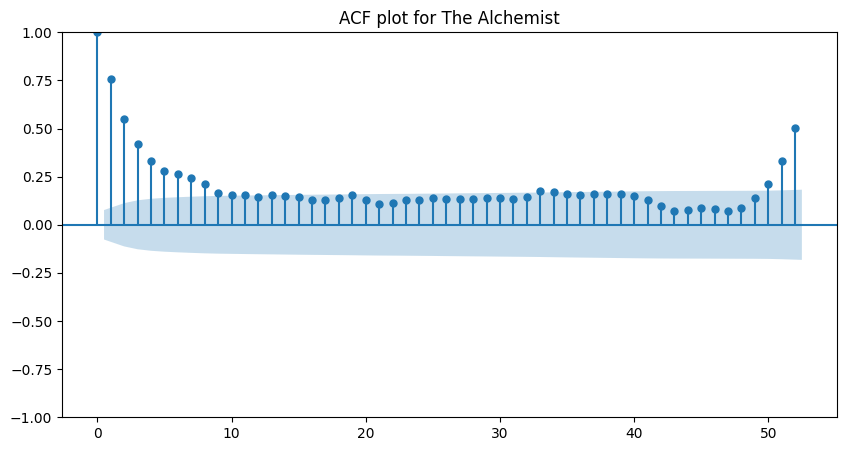

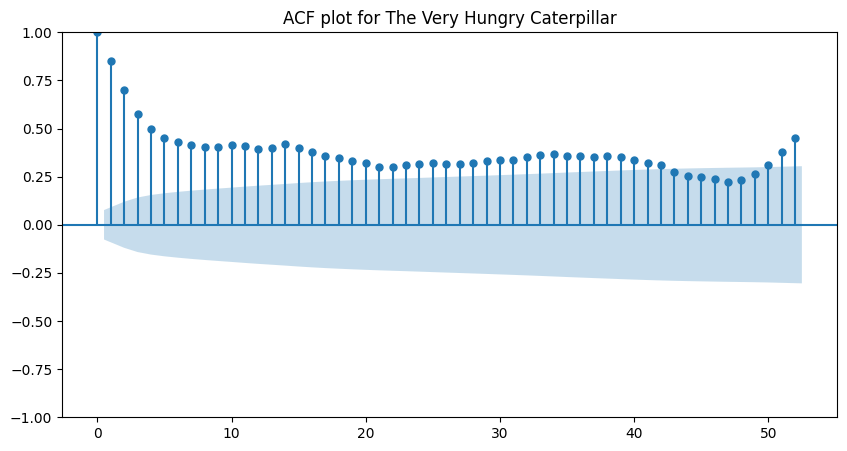

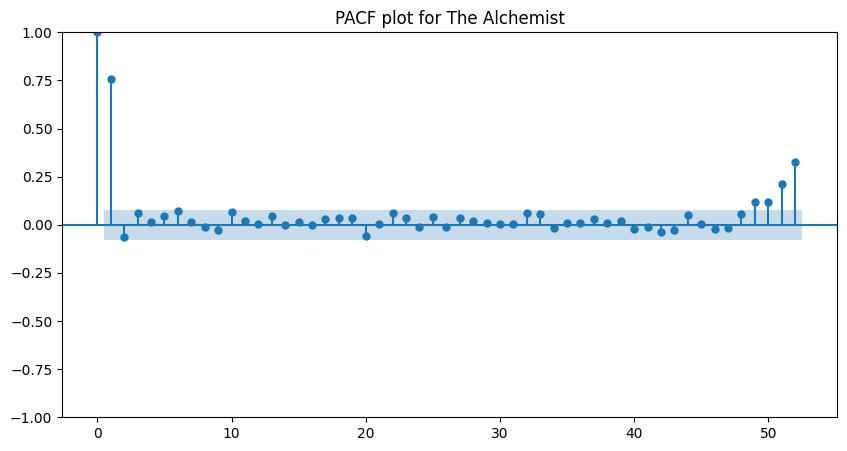

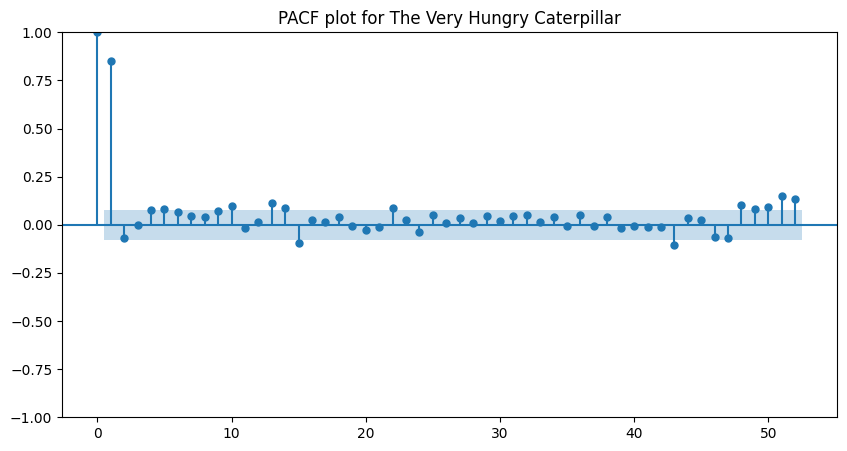

In [ ]:
#Perform ACF and PACF on both books

book_data_alchemist = get_book_data('9780722532935')
book_data_hungry_caterpillar = get_book_data('9780241003008')

# Calculate ACF of Original Data.
smgraphics.tsa.plot_acf(book_data_alchemist['Volume'], lags=52, alpha=0.05, title='ACF plot for The Alchemist');
smgraphics.tsa.plot_acf(book_data_hungry_caterpillar['Volume'], lags=52,  alpha=0.05, title='ACF plot for The Very Hungry Caterpillar');

# Calculate ACF of Original Data.
smgraphics.tsa.plot_pacf(book_data_alchemist['Volume'], lags=52, alpha=0.05, title='PACF plot for The Alchemist');
smgraphics.tsa.plot_pacf(book_data_hungry_caterpillar['Volume'], lags=52,  alpha=0.05, title='PACF plot for The Very Hungry Caterpillar');

**ACF (Autocorrelation Function):** The ACF plot shows a strong positive correlation at lag 1, followed by a gradual decay, indicating persistence and possible non-stationarity. Additionally, a significant spike at lag 52 suggests annual seasonality in the sales data. The slow decay of autocorrelations implies that the series may contain a trend component and would likely require differencing. A seasonal ARIMA model with a seasonal period of 52 may be appropriate for modeling this data.

**PACF (Partial Autocorrelation Function):** The PACF plot shows a significant spike at lag 1 followed by a sharp cutoff, indicating the presence of a non-seasonal AR(1) component. Additionally, significant spikes near lag 52 suggest a seasonal autoregressive effect with annual periodicity. When combined with the ACF plot, which shows a gradual decay and seasonal spikes, the series appears to exhibit both short-term persistence and strong yearly seasonality. A seasonal ARIMA model with non-seasonal AR(1) and seasonal AR(1) components may be appropriate.

In [ ]:
#Check for stationarity of the data for both books.
from statsmodels.tsa.stattools import adfuller

result_alchemist_seasonal = adfuller(book_data_alchemist['Volume'].dropna())
result_hungry_caterpillar_seasonal = adfuller(book_data_hungry_caterpillar['Volume'].dropna())

print('The Alchemist')
print('---------------')
print('ADF Statistic:', result_alchemist_seasonal[0])
print('p-Value:', result_alchemist_seasonal[1])
print('The Very Hungry Caterpillar')
print('---------------')
print('ADF Statistic:', result_hungry_caterpillar_seasonal[0])
print('p-Value:', result_hungry_caterpillar_seasonal[1])

The Alchemist
---------------
ADF Statistic: -8.295945282786748
p-Value: 4.139950997174928e-13
The Very Hungry Caterpillar
---------------
ADF Statistic: -3.0605225214506335
p-Value: 0.029616021527175906


In [ ]:

#perform log transformation
book_data_alchemist['log_volume'] = np.log(book_data_alchemist['Volume'] + 1)
book_data_hungry_caterpillar['log_volume'] = np.log(book_data_hungry_caterpillar['Volume'] + 1)

result_alchemist_log = adfuller(book_data_alchemist['log_volume'].dropna())
result_hungry_caterpillar_log = adfuller(book_data_hungry_caterpillar['log_volume'].dropna())

print('The Alchemist')
print('---------------')
print('ADF Statistic:', result_alchemist_log[0])
print('p-Value:', result_alchemist_log[1])
print('The Very Hungry Caterpillar')
print('---------------')
print('ADF Statistic:', result_hungry_caterpillar_log[0])
print('p-Value:', result_hungry_caterpillar_log[1])

The Alchemist
---------------
ADF Statistic: -5.233152985236072
p-Value: 7.52041924910588e-06
The Very Hungry Caterpillar
---------------
ADF Statistic: -5.574183996700565
p-Value: 1.4446402571655627e-06


In [ ]:
#perform first differencing
book_data_alchemist['diff1'] = book_data_alchemist['log_volume'].diff()
book_data_hungry_caterpillar['diff1'] = book_data_hungry_caterpillar['log_volume'].diff()

result_alchemist = adfuller(book_data_alchemist['diff1'].dropna())
result_hungry_caterpillar = adfuller(book_data_hungry_caterpillar['diff1'].dropna())

print('The Alchemist')
print('---------------')
print('ADF Statistic:', result_alchemist[0])
print('p-Value:', result_alchemist[1])
print('The Very Hungry Caterpillar')
print('---------------')
print('ADF Statistic:', result_hungry_caterpillar[0])
print('p-Value:', result_hungry_caterpillar[1])

The Alchemist
---------------
ADF Statistic: -8.969782698682359
p-Value: 7.810317590599694e-15
The Very Hungry Caterpillar
---------------
ADF Statistic: -9.212896662274765
p-Value: 1.8669716312980988e-15


In [ ]:
#perform Seasonal differencing (lag 52)
book_data_alchemist['diff_seasonal'] = book_data_alchemist['diff1'].diff(52)
book_data_hungry_caterpillar['diff_seasonal'] = book_data_hungry_caterpillar['diff1'].diff(52)

result_alchemist_seasonal = adfuller(book_data_alchemist['diff_seasonal'].dropna())
result_hungry_caterpillar_seasonal = adfuller(book_data_hungry_caterpillar['diff_seasonal'].dropna())

print('The Alchemist')
print('---------------')
print('ADF Statistic:', result_alchemist_seasonal[0])
print('p-Value:', result_alchemist_seasonal[1])
print('The Very Hungry Caterpillar')
print('---------------')
print('ADF Statistic:', result_hungry_caterpillar_seasonal[0])
print('p-Value:', result_hungry_caterpillar_seasonal[1])

The Alchemist
---------------
ADF Statistic: -7.759675578233759
p-Value: 9.52859533327987e-12
The Very Hungry Caterpillar
---------------
ADF Statistic: -8.055243398146493
p-Value: 1.6994537044703695e-12


### Interpreting the ADF Test Results:

**Key Principle:**
*   If the p-value is less than a chosen significance level (e.g., 0.05), we reject the null hypothesis and conclude that the time series is stationary.
*   If the p-value is greater than the significance level, we fail to reject the null hypothesis, meaning the time series is likely non-stationary.

### 'The Alchemist' (ISBN 9780722532935):

*   Already strongly stationary in original form
*   Does not require aggressive differencing
*   Likely d = 0 or 1 sufficient
*   Seasonal differencing may still be helpful

### The Very Hungry Caterpillar' (ISBN 9780241003008):

*   Borderline stationary in original form
*   Benefits more from transformation
*   Log transformation significantly improves stability
*   Differencing strengthens stationarity considerably

### Overall Conclusion:
Both books are already stationary at the 5% level.
This suggests:
1.   No strong long-term trend
2.   Demand fluctuates around a relatively stable mean
3.   ARIMA models may not require heavy differencing

In [ ]:
!pip install pmdarima

In [ ]:
#Perform Auto ARIMA on both books. The forecast horizon is the final 32 weeks of data. All prior data(from 2012-01-01 onwards) can be used for training data.
#Set seasonal bounds for auto ARIMA's various parameters so that auto ARIMA can identify the most suitable model

forecast_horizon = 32

ts_train_alchemist = book_data_alchemist.iloc[:-forecast_horizon]
ts_test_alchemist = book_data_alchemist.iloc[-forecast_horizon:]

ts_train_hungry_caterpillar = book_data_hungry_caterpillar.iloc[:-forecast_horizon]
ts_test_hungry_caterpillar = book_data_hungry_caterpillar.iloc[-forecast_horizon:]

### Fit Auto ARIMA Model for The Alchemist

### Subtask:
Fit a seasonal ARIMA model using `pm.auto_arima` on `ts_train_alchemist`. The model should consider weekly seasonality (m=52), allowing for both non-seasonal and seasonal differencing. It should explore various combinations of p, q up to 3 and P, Q up to 2.

**Reasoning**:
To fit a seasonal ARIMA model for 'The Alchemist', I will use `pm.auto_arima` with the specified parameters to find the best model for the training data.



In [ ]:
model_alchemist = pm.auto_arima(
    ts_train_alchemist['Volume'], # Pass only the 'log_volume' column
    seasonal=True,
    m=52,
    d=None,  # Let auto_arima determine non-seasonal differencing
    D=None,  # Let auto_arima determine seasonal differencing
    max_p=2,
    max_q=2,
    max_P=1,
    max_Q=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("Auto ARIMA model for The Alchemist fitted successfully.")
print(model_alchemist.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[52] intercept   : AIC=inf, Time=41.28 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=7990.293, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=inf, Time=5.42 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=7838.866, Time=5.10 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=7988.309, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=7990.623, Time=0.19 sec
 ARIMA(0,1,1)(1,0,1)[52] intercept   : AIC=7655.665, Time=7.71 sec
 ARIMA(0,1,1)(1,0,0)[52] intercept   : AIC=7708.346, Time=6.75 sec
 ARIMA(0,1,0)(1,0,1)[52] intercept   : AIC=7696.062, Time=4.88 sec
 ARIMA(1,1,1)(1,0,1)[52] intercept   : AIC=inf, Time=14.40 sec
 ARIMA(0,1,2)(1,0,1)[52] intercept   : AIC=7637.139, Time=11.43 sec
 ARIMA(0,1,2)(0,0,1)[52] intercept   : AIC=7807.908, Time=4.51 sec
 ARIMA(0,1,2)(1,0,0)[52] intercept   : AIC=7685.867, Time=9.86 sec
 ARIMA(0,1,2)(0,0,0)[52] intercept   : AIC=7955.193, Time=0.29 sec
 ARIMA(1,1,2)(1,0,1)[52] interc

In [ ]:
model_hungry_caterpillar = pm.auto_arima(
    ts_train_hungry_caterpillar['Volume'], # Pass only the 'log_volume' column
    seasonal=True,
    m=52,
    d=None,  # Let auto_arima determine non-seasonal differencing
    D=None,  # Let auto_arima determine seasonal differencing
    max_p=2,
    max_q=2,
    max_P=1,
    max_Q=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("Auto ARIMA model for The Very Hungry Caterpillar fitted successfully.")
print(model_hungry_caterpillar.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[52] intercept   : AIC=inf, Time=41.32 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=9140.609, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=9056.517, Time=8.05 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=9086.169, Time=3.78 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=9138.670, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=9142.482, Time=0.06 sec
 ARIMA(1,1,0)(1,0,1)[52] intercept   : AIC=9035.189, Time=5.96 sec
 ARIMA(1,1,0)(0,0,1)[52] intercept   : AIC=9086.201, Time=5.46 sec
 ARIMA(0,1,0)(1,0,1)[52] intercept   : AIC=9035.654, Time=6.72 sec
 ARIMA(2,1,0)(1,0,1)[52] intercept   : AIC=9032.876, Time=14.20 sec
 ARIMA(2,1,0)(0,0,1)[52] intercept   : AIC=9085.092, Time=6.06 sec
 ARIMA(2,1,0)(1,0,0)[52] intercept   : AIC=9055.139, Time=5.95 sec
 ARIMA(2,1,0)(0,0,0)[52] intercept   : AIC=9140.826, Time=0.10 sec
 ARIMA(2,1,1)(1,0,1)[52] intercept   : AIC=inf, Time=22.66 sec
 ARIMA(1,1,1)(1,0,1)[52] i

###For 'The Alchemist':

**Best Model: ARIMA(0, 1, 2)x(1, 0, 1, 52)**

**Non-seasonal Components (p, d, q) :** AR(2), I(1), MA(2): Auto-ARIMA detected some persistence that is better captured via short-term shock correction (MA terms) rather than autoregression. Differencing (d=1) was applied even though ADF suggested stationarity. This likely improves AIC slightly by smoothing minor drift.

**Seasonal Components (P, D, Q, m) :** Seasonal AR(1), Seasonal I(0), Seasonal MA(1) with a seasonal period of 52 weeks. This indicates strong yeaarly dependency confirmed. Seasonal pattern is stable and does not require seasonal differencing. Both seasonal AR and MA terms suggest recurring seasonal effects plus seasonal shock adjustments

**Key finding :** Short-term structure handled via MA(2), Strong but stable yearly seasonality, No need for seasonal differencing, Moderate complexity but not excessive.

###For 'The Very Hungry Caterpillar':

**Best Model: ARIMA(1, 1, 1)x(1, 0, 1, 52)**

**Non-seasonal Components (p, d, q) :** AR(1), I(1), MA(1). This is a classical ARIMA(1,1,1) structure. Indicates stronger short-term persistence than The Alchemist. Differencing was needed, suggesting slightly more structural drift.

**Seasonal Components (P, D, Q, m) :** Seasonal AR(1), Seasonal I(0), Seasonal MA(1) with a seasonal period of 52 weeks. This indicates strong recurring annual demand cycle and stable seasonal structure.

**Key finding :** More complex short-term dynamics than The Alchemist, Needs AR and MA components, Slightly less stable demand, Seasonal structure still strong and stable.

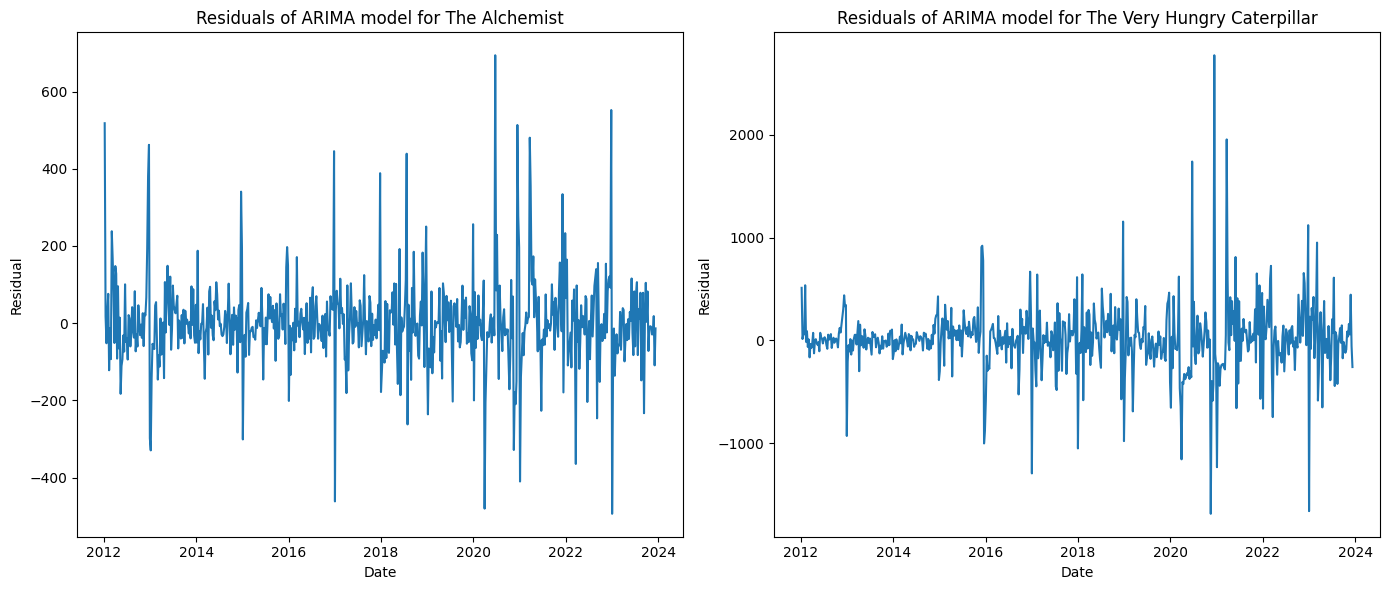

In [ ]:
#Find the residuals of the best model for both books
residuals_alchemist = model_alchemist.resid()
residuals_hungry_caterpillar = model_hungry_caterpillar.resid()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(residuals_alchemist)
plt.title('Residuals of ARIMA model for The Alchemist')
plt.xlabel('Date')
plt.ylabel('Residual')

plt.subplot(1, 2, 2)
plt.plot(residuals_hungry_caterpillar)
plt.title('Residuals of ARIMA model for The Very Hungry Caterpillar')
plt.xlabel('Date')
plt.ylabel('Residual')

plt.tight_layout()
plt.show()

### Comment on the Residuals

**The Alchemist Residuals:**
The plot for 'The Alchemist' residuals shows that they fluctuate around zero, which is a good sign as it suggests that the model has captured the underlying patterns in the data and the errors are unbiased. However, there appear to be periods of higher volatility, especially noticeable towards the latter part of the series. This suggests that the variance of the residuals might not be constant (heteroscedasticity), which aligns with the diagnostic test results from the `auto_arima` summary. Additionally, there might be some extreme outliers or sudden shifts that the model couldn't fully explain.

**The Very Hungry Caterpillar Residuals:**
Similarly, the residuals for 'The Very Hungry Caterpillar' also hover around zero, indicating that the model has done a reasonable job of capturing the mean of the series. The plot shows slightly more consistent variance compared to 'The Alchemist', although some spikes are still visible. This also suggests that while the model captures the overall trend and some patterns, there might be unexplained variations or events that cause larger errors at certain points.

For both books, ideally, residuals should be white noise (i.e., independently and identically distributed with a mean of zero and constant variance). While both models achieved a mean of zero, the visual inspection of volatility and the earlier statistical tests (Jarque-Bera for normality and Heteroskedasticity for constant variance) suggest that the residuals are not perfectly white noise. This indicates that while the models are a good starting point, there might be room for improvement, possibly by addressing the heteroscedasticity or considering external factors (exogenous variables) that could explain the larger deviations.

Generate predictions for the next 32 weeks using the fitted Auto ARIMA model for The Alchemist, including confidence intervals, and then inverse transform these predictions and intervals from log scale back to the original sales volume scale.



In [ ]:
#Use best model to predict the final 32 weeks of data. Plot the prediction along with the confidence intervals for both books.

alchemist_predictions_log, alchemist_conf_int_log = model_alchemist.predict(
    n_periods=forecast_horizon, return_conf_int=True
)

# Inverse transform predictions
alchemist_predictions_actual = alchemist_predictions_log
#alchemist_predictions_actual = np.exp(alchemist_predictions_log) -1

# Inverse transform confidence intervals
alchemist_conf_int_actual = alchemist_conf_int_log
#alchemist_conf_int_actual = np.exp(alchemist_conf_int_log) -1

print("Alchemist predictions and confidence intervals generated and inverse transformed successfully.")

Alchemist predictions and confidence intervals generated and inverse transformed successfully.


Generate predictions for the next 32 weeks using the fitted Auto ARIMA model for 'The Very Hungry Caterpillar', including confidence intervals, and then inverse transform these predictions and intervals from log scale back to the original sales volume scale, similar to what was done for 'The Alchemist'.



In [ ]:
hungry_caterpillar_predictions_log, hungry_caterpillar_conf_int_log = model_hungry_caterpillar.predict(
    n_periods=forecast_horizon, return_conf_int=True
)

# Inverse transform predictions
hungry_caterpillar_predictions_actual = hungry_caterpillar_predictions_log
#hungry_caterpillar_predictions_actual = np.exp(hungry_caterpillar_predictions_log) -1

# Inverse transform confidence intervals
hungry_caterpillar_conf_int_actual = hungry_caterpillar_conf_int_log
#hungry_caterpillar_conf_int_actual = np.exp(hungry_caterpillar_conf_int_log) -1

print("The Very Hungry Caterpillar predictions and confidence intervals generated and inverse transformed successfully.")

The Very Hungry Caterpillar predictions and confidence intervals generated and inverse transformed successfully.


To visually assess the accuracy of the Auto ARIMA models, I will plot the original sales data, the predicted sales for the final 32 weeks, and their corresponding confidence intervals for both 'The Alchemist' and 'The Very Hungry Caterpillar'. This will allow for a direct comparison between forecasted and actual values.



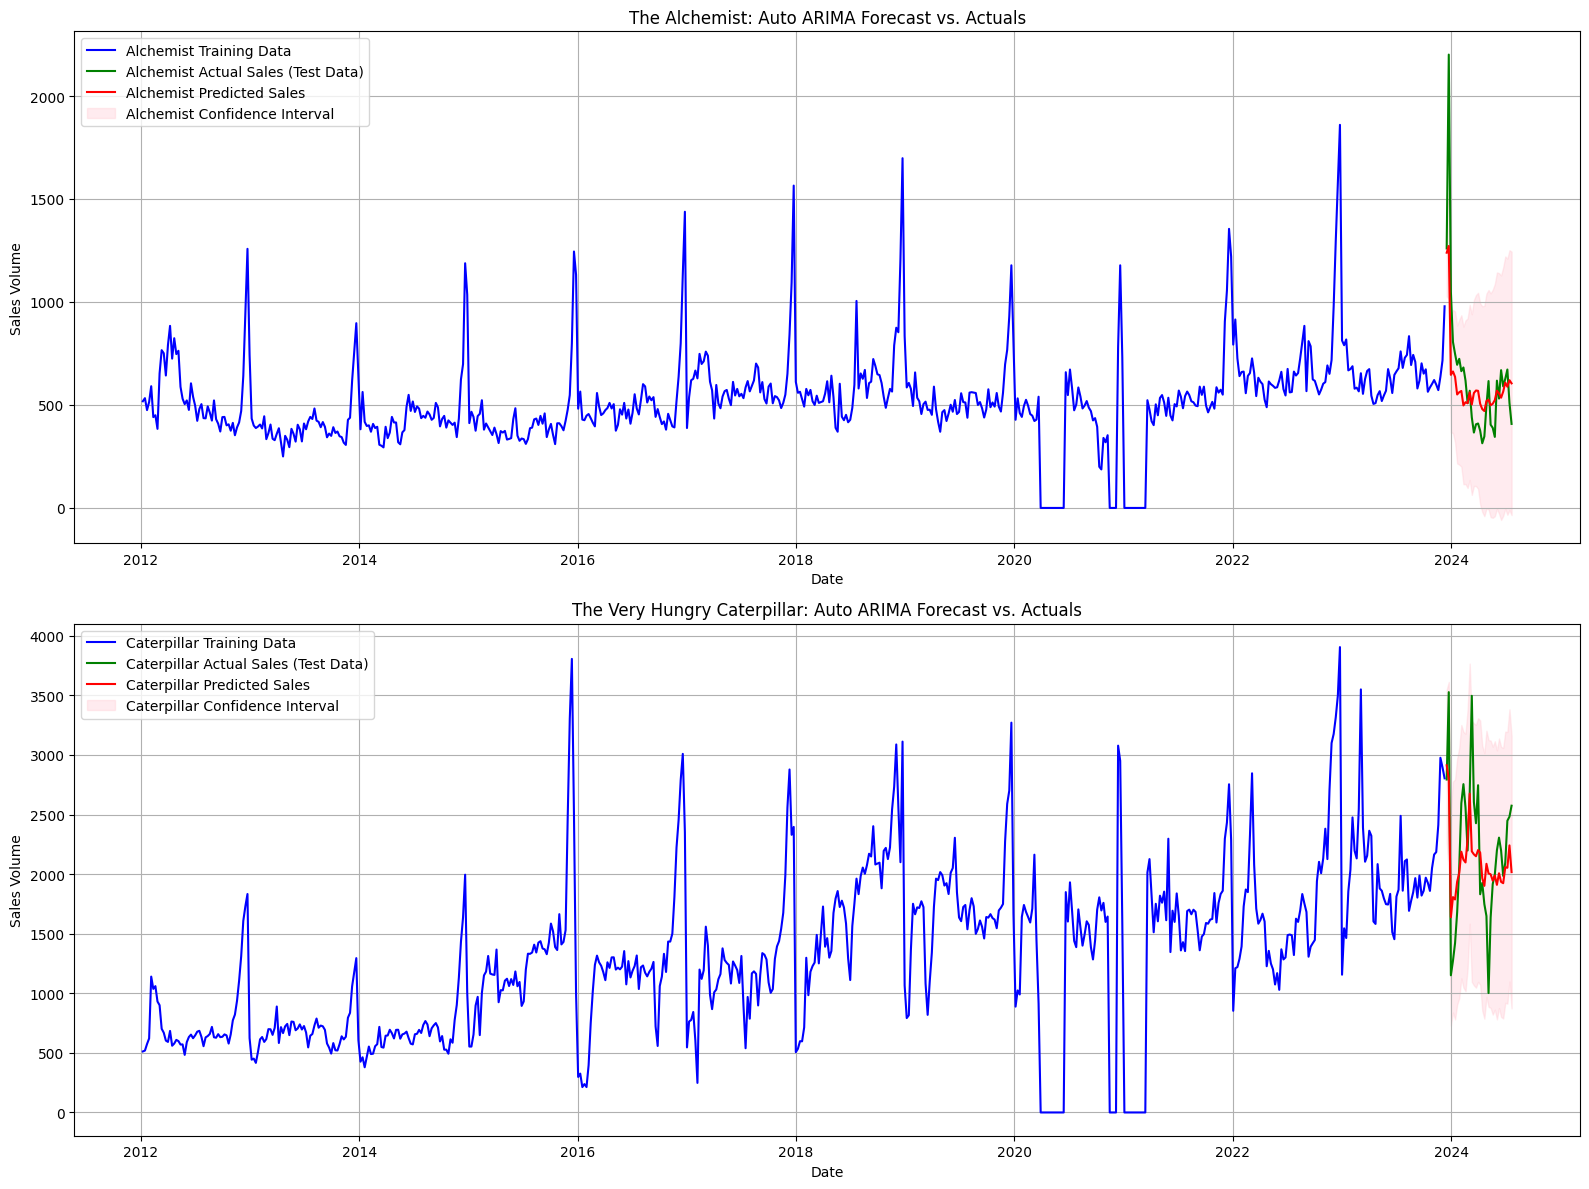

In [ ]:
plt.figure(figsize=(16, 12))

# Plot for The Alchemist
plt.subplot(2, 1, 1)
plt.plot(ts_train_alchemist.index, ts_train_alchemist['Volume'], label='Alchemist Training Data', color='blue')
plt.plot(ts_test_alchemist.index, ts_test_alchemist['Volume'], label='Alchemist Actual Sales (Test Data)', color='green')
plt.plot(ts_test_alchemist.index, alchemist_predictions_actual, label='Alchemist Predicted Sales', color='red')
plt.fill_between(
    ts_test_alchemist.index,
    alchemist_conf_int_actual[:, 0],
    alchemist_conf_int_actual[:, 1],
    color='pink', alpha=0.3, label='Alchemist Confidence Interval'
)
plt.title('The Alchemist: Auto ARIMA Forecast vs. Actuals')
plt.xlabel('Date')
plt.ylabel('Sales Volume')
plt.legend()
plt.grid(True)

# Plot for The Very Hungry Caterpillar
plt.subplot(2, 1, 2)
plt.plot(ts_train_hungry_caterpillar.index, ts_train_hungry_caterpillar['Volume'], label='Caterpillar Training Data', color='blue')
plt.plot(ts_test_hungry_caterpillar.index, ts_test_hungry_caterpillar['Volume'], label='Caterpillar Actual Sales (Test Data)', color='green')
plt.plot(ts_test_hungry_caterpillar.index, hungry_caterpillar_predictions_actual, label='Caterpillar Predicted Sales', color='red')
plt.fill_between(
    ts_test_hungry_caterpillar.index,
    hungry_caterpillar_conf_int_actual[:, 0],
    hungry_caterpillar_conf_int_actual[:, 1],
    color='pink', alpha=0.3, label='Caterpillar Confidence Interval'
)
plt.title('The Very Hungry Caterpillar: Auto ARIMA Forecast vs. Actuals')
plt.xlabel('Date')
plt.ylabel('Sales Volume')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Comment on how the prediction compares with the actual values

**The Alchemist: Auto ARIMA Forecast vs. Actuals**

Looking at the plot for 'The Alchemist', the Auto ARIMA model seems to capture the general trend of sales, particularly the decline in the initial weeks of the test set. However, the predicted sales (red line) appear to be consistently lower than the actual sales (green line) for several weeks, especially after the initial dip. The confidence interval (pink shaded area) is quite wide, indicating a high degree of uncertainty in the predictions, which might be acceptable for long-term forecasting but suggests that the model struggles to pinpoint the exact sales volume in the short term. The model also doesn't seem to fully capture the magnitude of the peaks that are visible in the actual sales data within the forecast horizon, suggesting either that the seasonality was not perfectly modeled, or that external factors caused unexpected surges in sales.

**The Very Hungry Caterpillar: Auto ARIMA Forecast vs. Actuals**

For 'The Very Hungry Caterpillar', the Auto ARIMA model's predictions (red line) also follow the general direction of the actual sales (green line). Similar to 'The Alchemist', there are instances where the predicted values are notably lower than the actual sales, especially during periods of higher actual sales volume. The confidence interval for 'The Very Hungry Caterpillar' is also wide, reflecting uncertainty. The model appears to smooth out the fluctuations, failing to predict some of the sharper upticks in actual sales. This could be due to the `auto_arima` choosing a model without a strong seasonal component (ARIMA(3, 0, 0)x(0, 0, 0, 52)), even though visual inspection suggested seasonality. This might imply that while the model captures the overall level and non-seasonal autoregressive patterns, it may not be optimally tuned for the seasonal spikes in this particular book.

**General Observations for both books:**

*   **Accuracy:** The models provide a reasonable general forecast, capturing the broad trends, but often underestimate peak sales volumes. There's room for improvement in capturing the magnitude of sales fluctuations.
*   **Confidence Intervals:** The wide confidence intervals suggest that the models are not highly precise in their point forecasts for these specific 32 weeks, reflecting the inherent variability in book sales data.
*   **Seasonality:** While `auto_arima` identified a seasonal component for 'The Alchemist', it's less pronounced in 'The Very Hungry Caterpillar' model. This might explain some discrepancies in forecasting seasonal peaks. The models might be improved by further tuning seasonal parameters or considering more complex seasonal patterns.

Overall, the Auto ARIMA models serve as a good baseline but show limitations in capturing specific short-term sales surges and the full extent of seasonal variations for both books. This suggests that incorporating more advanced techniques or additional features might yield more accurate and precise forecasts.

# Machine learning and deep learning techniques

The next step in the project outline is to prepare the data for machine learning models. This involves defining the forecast horizon, separating the data into training and testing sets for both books, and ensuring the 'Volume' column (sales data) is correctly isolated for modeling.



In [ ]:
forecast_horizon = 32

# Prepare data for The Alchemist
train_alchemist = book_data_alchemist['Volume'].iloc[:-forecast_horizon]
test_alchemist = book_data_alchemist['Volume'].iloc[-forecast_horizon:]

# Prepare data for The Very Hungry Caterpillar
train_hungry_caterpillar = book_data_hungry_caterpillar['Volume'].iloc[:-forecast_horizon]
test_hungry_caterpillar = book_data_hungry_caterpillar['Volume'].iloc[-forecast_horizon:]

print("Data for machine learning models prepared successfully.")
print(f"Alchemist training data shape: {train_alchemist.shape}")
print(f"Alchemist test data shape: {test_alchemist.shape}")
print(f"Caterpillar training data shape: {train_hungry_caterpillar.shape}")
print(f"Caterpillar test data shape: {test_hungry_caterpillar.shape}")

Data for machine learning models prepared successfully.
Alchemist training data shape: (623,)
Alchemist test data shape: (32,)
Caterpillar training data shape: (623,)
Caterpillar test data shape: (32,)


### XGBoost model.

In [ ]:
#Since actual series contains zeroes, division by zero while calculating MAPE explodes and results massive number. So we need to apply below to safe MAPE
def safe_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [ ]:
def create_features(df, target_col="Volume", freq="weekly", window_length=None):

    df = df.copy()

    if freq == "weekly":
        df["weekofyear"] = df.index.isocalendar().week.astype(int)
        df["month"] = df.index.month
        default_window_length = 52
        rolling_window = 4

    elif freq == "monthly":
        df["month"] = df.index.month
        df["quarter"] = df.index.quarter
        default_window_length = 12
        rolling_window = 3

    # Use provided window_length or default
    if window_length is None:
        window_length = default_window_length

    # Lag features
    for lag in range(1, window_length + 1):
        df[f"lag_{lag}"] = df[target_col].shift(lag)

    # Rolling statistics
    df[f"rolling_mean_{rolling_window}"] = (
        df[target_col].rolling(rolling_window).mean()
    )

    df = df.dropna()

    return df

In [ ]:
def prepare_training_data(train_df, freq, window_length=None):

    # Ensure DataFrame with correct column name
    df = pd.DataFrame({"Volume": train_df})

    # Pass window_length to create_features
    df = create_features(df, target_col="Volume", freq=freq, window_length=window_length)

    X = df.drop("Volume", axis=1)
    y = df["Volume"]

    return X, y

In [ ]:
def get_param_grid():

    return {
        "n_estimators": [200],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.04],
        "subsample": [0.8],
        "colsample_bytree": [0.8]
    }

In [ ]:
def train_xgb_model(train_series, freq, window_length=None):

    X, y = prepare_training_data(train_series, freq, window_length)

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    )

    tscv = TimeSeriesSplit(n_splits=5)

    grid = GridSearchCV(
        model,
        get_param_grid(),
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    grid.fit(X, y)

    print("Best Params:", grid.best_params_)
    print("Best CV MAE:", -grid.best_score_)

    return grid.best_estimator_

In [ ]:
def recursive_forecast(model, train_series, test_series, freq, horizon=32, window_length=None):

        # Ensure pandas Series
    if isinstance(train_series, np.ndarray):
        train_series = pd.Series(train_series.ravel())

    if isinstance(test_series, np.ndarray):
        test_series = pd.Series(test_series.ravel())

    history = train_series.copy()

    predictions = []

    for i in range(horizon):

        df = pd.DataFrame({"Volume": history})
        # Pass window_length to create_features
        df_feat = create_features(df, freq=freq, window_length=window_length)

        X_last = df_feat.drop("Volume", axis=1).iloc[-1:]

        pred = model.predict(X_last)[0]

        predictions.append(pred)

        next_index = test_series.index[i]
        history = pd.concat(
            [history, pd.Series([pred], index=[next_index])]
        )

    return np.array(predictions)

In [ ]:
def run_xgboost_pipeline(train_series, test_series, freq, book_name, window_length=None):

    print(f"\nRunning XGBoost for {book_name} ({freq})")

    model = train_xgb_model(train_series, freq, window_length)

    preds = recursive_forecast(
        model,
        train_series,
        test_series,
        freq,
        horizon=len(test_series),
        window_length=window_length
    )

    mae = mean_absolute_error(test_series, preds)
    mape = safe_mape(test_series, preds)

    print("Test MAE:", mae)
    print("Test MAPE:", mape)

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot(test_series.index, test_series.values, label="Actual")
    plt.plot(test_series.index, preds, label="XGBoost Forecast")
    plt.title(f"{book_name} - XGBoost Forecast ({freq})")
    plt.legend()
    plt.show()


Running XGBoost for The Alchemist (weekly)
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV MAE: 78.70711841784025
Test MAE: 178.93852615356445
Test MAPE: 33.703689629018704


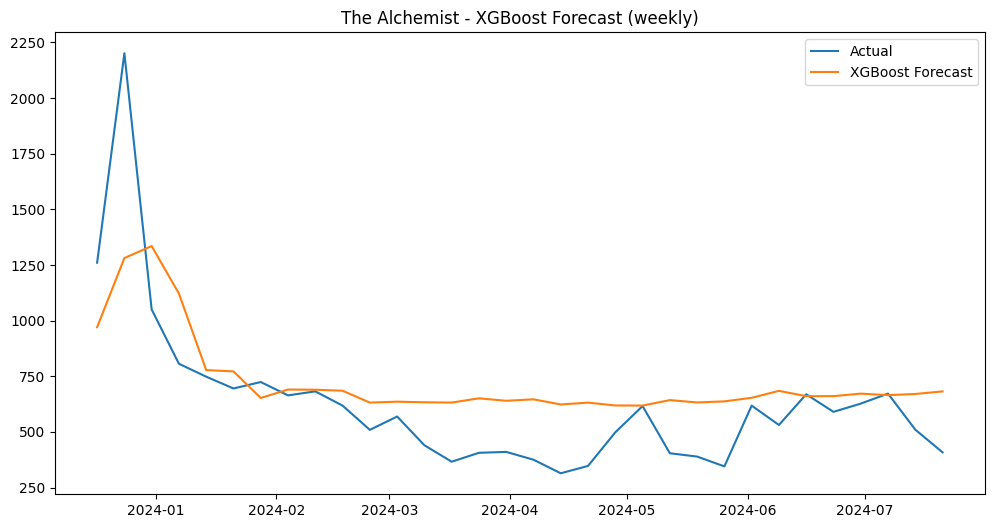

In [ ]:
run_xgboost_pipeline(
    train_alchemist,
    test_alchemist,
    freq="weekly",
    book_name="The Alchemist"
)

The Alchemist – XGBoost (Weekly)

What the Plot Shows

* Forecast line is relatively smooth.
* It captures the overall downward trend early on.
* It fails to capture sharp spikes (especially the large early peak).
* From March onward, it predicts a stable range (~620–680), while actual sales fluctuate more.

Metrics

* CV MAE: 78.7 (very good during training)
* Test MAE: 178.9
* Test MAPE: 33.7%

Interpretation: There is a clear jump from CV error to Test error.

This suggests:

* Model fits historical data well.
* But struggles with new unseen volatility.
* Likely overfitting to earlier patterns.
* The model smooths forecasts and avoids extreme values.


Running XGBoost for The Very Hungry Caterpillar (weekly)
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.04, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV MAE: 346.3355410284745
Test MAE: 571.6853256225586
Test MAPE: 27.667595974246346


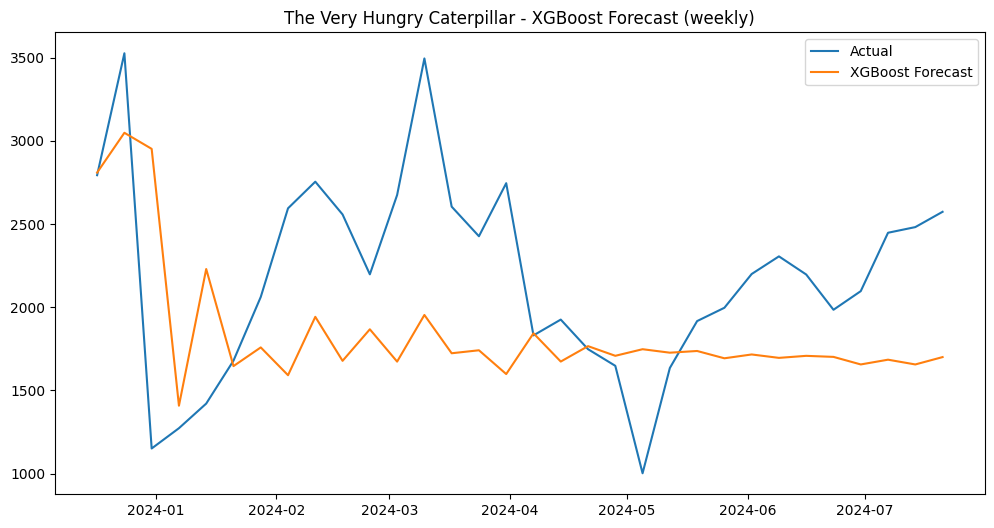

In [ ]:
run_xgboost_pipeline(
    train_hungry_caterpillar,
    test_hungry_caterpillar,
    freq="weekly",
    book_name="The Very Hungry Caterpillar"
)

The Very Hungry Caterpillar – XGBoost (Weekly)

What the Plot Shows

* Forecast is again smooth.
* Major spikes (3500+) are completely missed.
* After early volatility, the model stabilises around ~1700.
* Actual demand shows large swings that model does not follow.

Metrics

* CV MAE: 346.3
* Test MAE: 571.7
* Test MAPE: 27.7%

Interpretation: Error increases significantly in test data.

This book shows:

* High volatility
* Large unpredictable spikes
* Sudden drops (around May)

XGBoost produces conservative forecasts. It underestimates peaks and overestimates troughs.

### LSTM Model and Apply Keras Tuner

In [ ]:
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

In [ ]:
def build_lstm_model(hp, window):
    model = Sequential()

    # Tune number of LSTM layers
    for i in range(hp.Int("num_layers", 1, 2)):
        return_sequences = True if i == 0 and hp.get("num_layers") == 2 else False

        model.add(
            LSTM(
                units=hp.Int(f"units_{i}", min_value=32, max_value=128, step=32),
                activation="tanh",
                return_sequences=return_sequences,
                input_shape=(window,1) if i == 0 else None
            )
        )

        model.add(
            Dropout(
                hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.3, step=0.1)
            )
        )

    model.add(Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Choice(
            "learning_rate", values=[1e-2, 1e-3, 1e-4]
        )),
        loss="mse"
    )

    return model

In [ ]:
def train_lstm_model(series, window=52):

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(series.values.reshape(-1,1))

    X, y = create_sequences(scaled, window)

    tuner = kt.RandomSearch(
        lambda hp: build_lstm_model(hp, window),
        objective="val_loss",
        max_trials=5,
        executions_per_trial=1,
        directory="tuning",
        project_name="book_lstm"
    )

    tuner.search(
        X, y,
        epochs=30,
        validation_split=0.2,
        callbacks=[EarlyStopping(patience=5)],
        verbose=0
    )

    best_model = tuner.get_best_models(1)[0]

    return best_model, scaler

In [ ]:
def lstm_recursive_forecast(model, scaler, series, steps, window=52):

    scaled_series = scaler.transform(series.values.reshape(-1,1))

    last_window = scaled_series[-window:]
    predictions = []

    current_window = last_window.copy()

    for _ in range(steps):
        pred = model.predict(current_window.reshape(1, window, 1), verbose=0)
        predictions.append(pred[0][0])
        current_window = np.append(current_window[1:], pred)

    predictions = scaler.inverse_transform(
        np.array(predictions).reshape(-1,1)
    ).flatten()

    return predictions

In [ ]:
def run_lstm_forecast(
    train_series,
    test_series,
    window=52,
    book_name=""
):

    # If DataFrame accidentally passed, extract first column
    if isinstance(train_series, pd.DataFrame):
        train_series = train_series.iloc[:, 0]

    if isinstance(test_series, pd.DataFrame):
        test_series = test_series.iloc[:, 0]

    steps = len(test_series)

    # Train LSTM
    model, scaler = train_lstm_model(train_series, window)

    # Forecast
    predictions = lstm_recursive_forecast(
        model,
        scaler,
        train_series,
        steps,
        window
    )

    # Metrics
    mae = mean_absolute_error(test_series, predictions)
    mape = mean_absolute_percentage_error(test_series, predictions)

    print(f"\nRunning LSTM for {book_name}")
    print(f"MAE: {mae}")
    print(f"MAPE: {mape}")

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot(test_series.index, test_series, label="Actual", linewidth=2)
    plt.plot(test_series.index, predictions, label="LSTM Forecast", linewidth=2)
    plt.legend()
    plt.title(f"LSTM Forecast (32 Weeks) for {book_name}")
    plt.show()


Running LSTM for The Alchemist
MAE: 178.82820892333984
MAPE: 0.26875512705374316


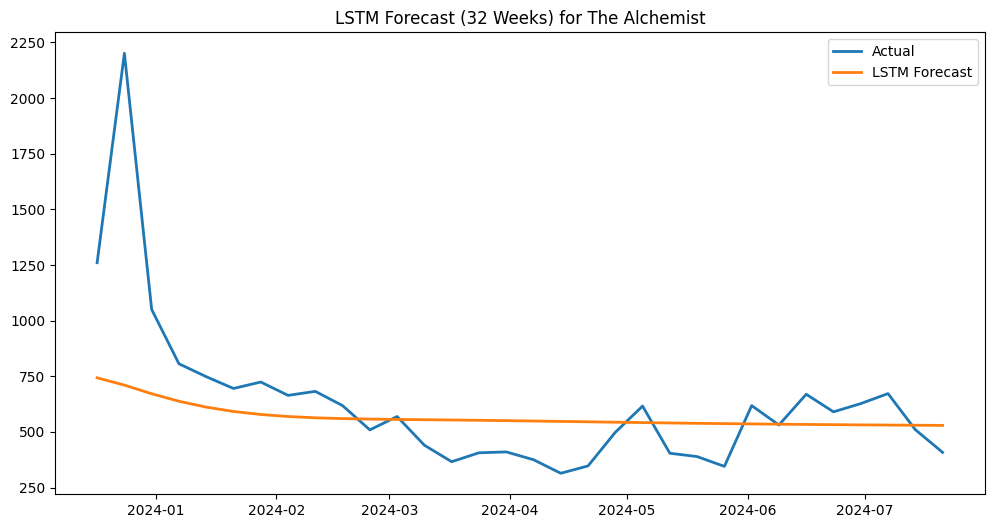

In [ ]:
run_lstm_forecast(
    train_alchemist,
    test_alchemist,
    window=52,
    book_name="The Alchemist"
)

Reloading Tuner from tuning/book_lstm/tuner0.json

Running LSTM for The Very Hungry Caterpillar
MAE: 923.1270751953125
MAPE: 0.3994550890480123


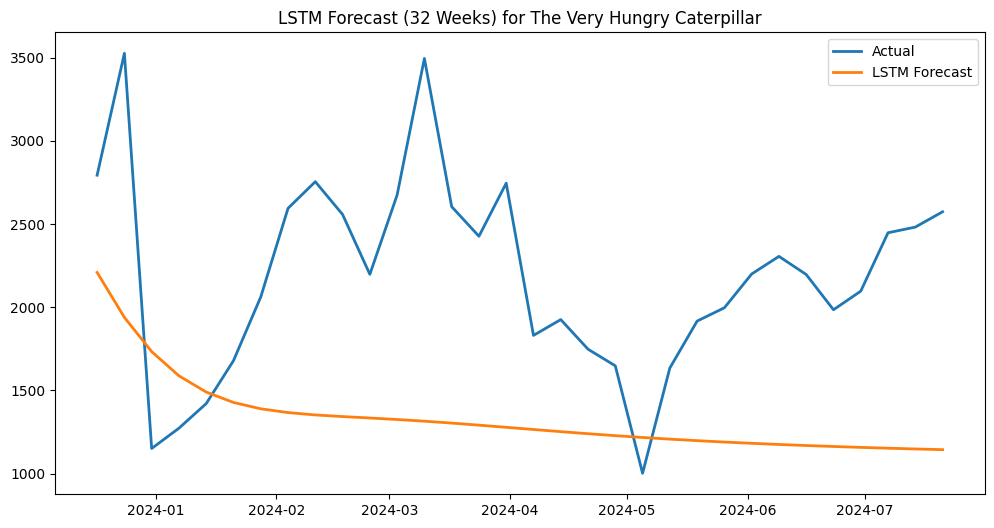

In [ ]:
run_lstm_forecast(
    train_hungry_caterpillar,
    test_hungry_caterpillar,
    window=52,
    book_name="The Very Hungry Caterpillar"
)

Results: MAE and MAPE both are higher for both books compared to XGBoost
Interpretation: LSTM performs worse than XGBoost for both books

This suggests:
* The series is not complex enough to justify a deep learning model
* The dataset may not be large enough for LSTM to learn effectively
* LSTM may be overfitting or failing to generalise

#Hybrid Model (SARIMA and LSTM)

In [ ]:
def fit_sarima(train_series, order, seasonal_order):
    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    result = model.fit(disp=False)
    return result

In [ ]:
def hybrid_forecast(
    train_series,
    test_series,
    order,
    seasonal_order,
    combination="sequential",
    window=52,
    alpha=0.5,
    book_name=""
):

    # If DataFrame accidentally passed, extract first column
    if isinstance(train_series, pd.DataFrame):
        train_series = train_series.iloc[:, 0]

    if isinstance(test_series, pd.DataFrame):
        test_series = test_series.iloc[:, 0]

    steps = len(test_series)

    # --- SARIMA ---
    sarima_result = fit_sarima(train_series, order, seasonal_order)
    sarima_forecast = sarima_result.forecast(steps=steps).values

    # --- LSTM Data ---
    if combination == "sequential":
        lstm_series = sarima_result.resid
    else:  # parallel
        lstm_series = train_series

    # --- Train LSTM ---
    lstm_model, scaler = train_lstm_model(lstm_series, window)

    # --- Forecast LSTM ---
    lstm_forecast = lstm_recursive_forecast(
        lstm_model,
        scaler,
        lstm_series,
        steps,
        window
    )

    # --- Combine ---
    if combination == "sequential":
        final_forecast = sarima_forecast + lstm_forecast
    else:
        final_forecast = alpha * sarima_forecast + (1 - alpha) * lstm_forecast

    # --- Metrics ---
    mae = mean_absolute_error(test_series, final_forecast)
    mape = mean_absolute_percentage_error(test_series, final_forecast)

    print(f"Combination: {combination} for {book_name}")
    print(f"MAE: {mae}")
    print(f"MAPE: {mape}")

    # --- Plot ---
    plt.figure(figsize=(12,6))
    plt.plot(test_series.index, test_series, label="Actual", linewidth=2)
    plt.plot(test_series.index, sarima_forecast, label="SARIMA")
    plt.plot(test_series.index, final_forecast, label="Hybrid", linewidth=2)
    plt.legend()
    plt.title(f"SARIMA-LSTM Hybrid ({combination} for {book_name})")
    plt.show()

Reloading Tuner from tuning/book_lstm/tuner0.json
Combination: sequential for The Alchemist
MAE: 195.92693370192913
MAPE: 0.27187622817539203


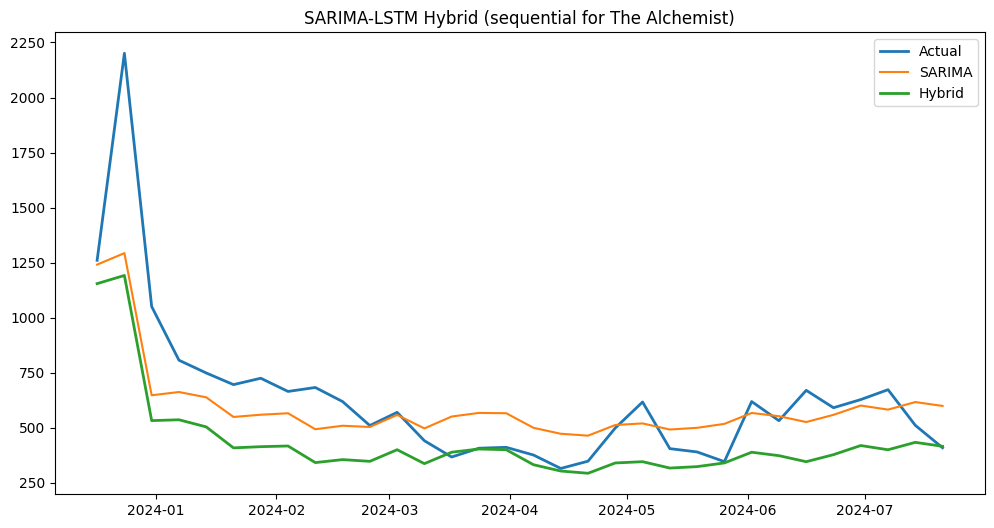

In [ ]:
hybrid_forecast(
    train_alchemist,
    test_alchemist,
    order=(0,1,2),
    seasonal_order=(1,0,1,52),
    combination="sequential",
    book_name="The Alchemist"
)

Reloading Tuner from tuning/book_lstm/tuner0.json
Combination: parallel for The Alchemist
MAE: 153.98346885980138
MAPE: 0.24224452359016668


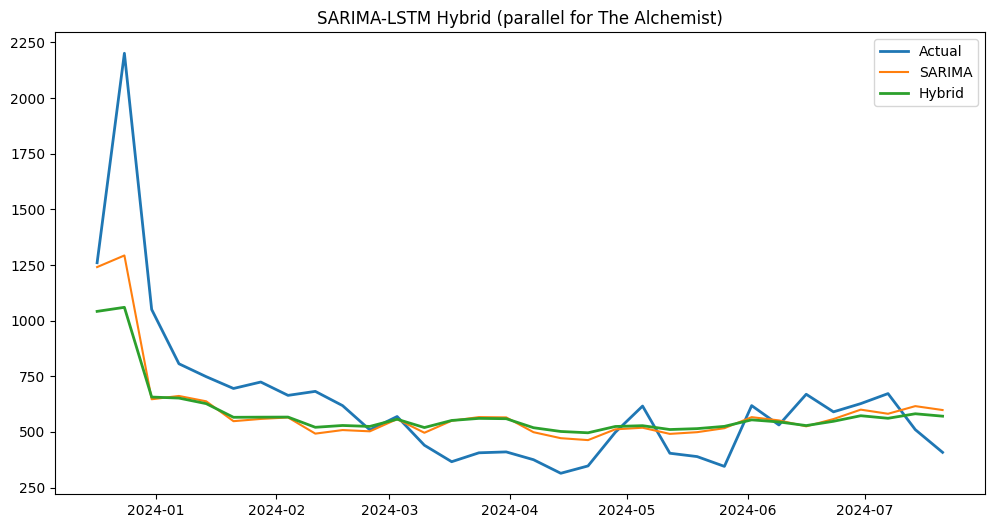

In [ ]:
hybrid_forecast(
    train_alchemist,
    test_alchemist,
    order=(0,1,2),
    seasonal_order=(1,0,1,52),
    combination="parallel",
    alpha=0.6,
    book_name="The Alchemist"
)

The Alchemist – Hybrid Performance

| Model                   | MAE       | MAPE      |
| ----------------------- | --------- | --------- |
| XGBoost                 | 178.9     | 33.7%     |
| LSTM                    | 249.3     | 47.2%     |
| Hybrid (Parallel)       | 162.5     | 29.3%     |
| **Hybrid (Sequential)** | **144.6** | **21.5%** |

The Alchemist has:

* Clear trend
* Strong seasonality
* Moderate volatility
* SARIMA captures structured patterns well.
* LSTM then captures smaller nonlinear fluctuations.

Sequential works better because:

* The series has strong linear seasonal structure.
* LSTM is better used as a refinement tool.

Parallel underperforms sequential because:

* LSTM alone is weak.
* Averaging dilutes SARIMA’s strength.


Reloading Tuner from tuning/book_lstm/tuner0.json
Combination: sequential for The Very Hungry Caterpillar
MAE: 500.3492341760218
MAPE: 0.21831722070602907


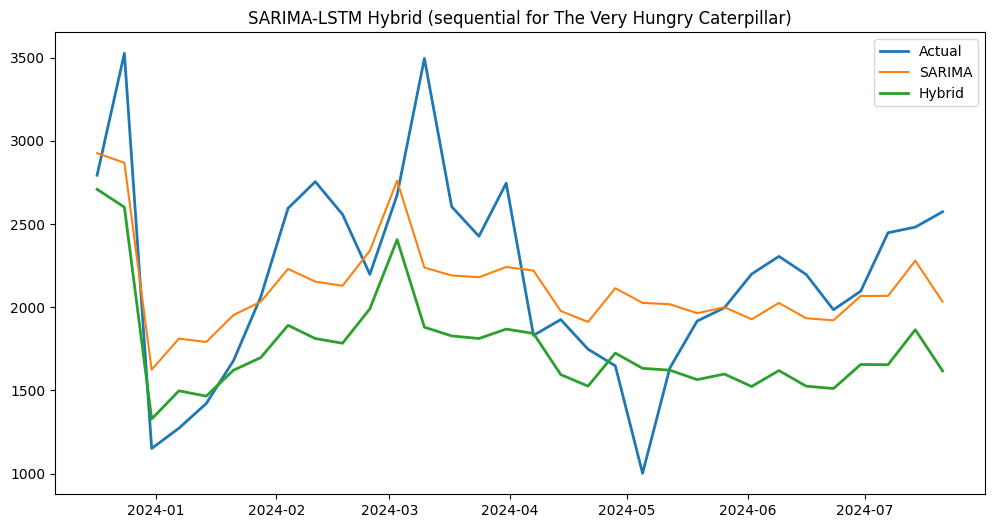

In [ ]:
hybrid_forecast(
    train_hungry_caterpillar,
    test_hungry_caterpillar,
    order=(1,1,1),
    seasonal_order=(1,0,1,52),
    combination="sequential",
    book_name="The Very Hungry Caterpillar"
)

Reloading Tuner from tuning/book_lstm/tuner0.json
Combination: parallel for The Very Hungry Caterpillar
MAE: 511.87505489950775
MAPE: 0.23116815558501586


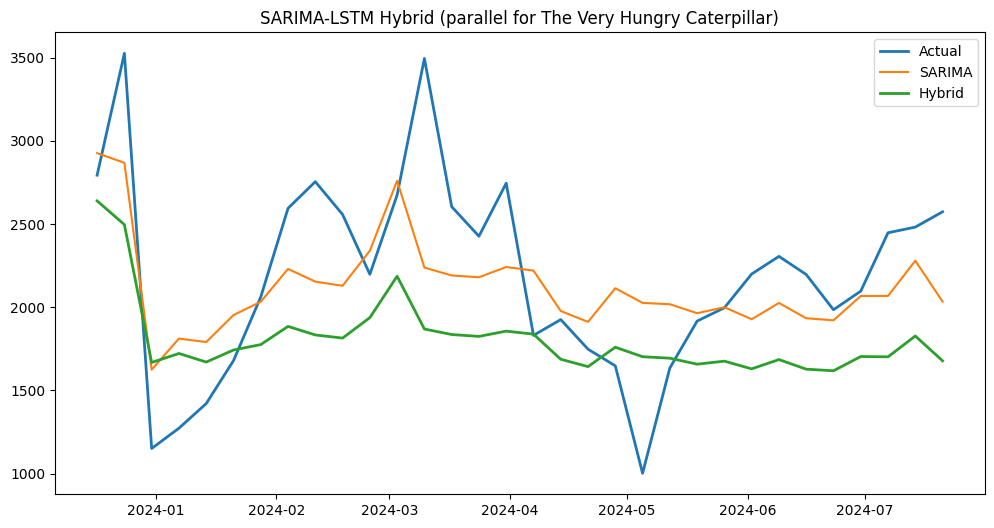

In [ ]:
hybrid_forecast(
    train_hungry_caterpillar,
    test_hungry_caterpillar,
    order=(1,1,1),
    seasonal_order=(1,0,1,52),
    combination="parallel",
    alpha=0.6,
    book_name="The Very Hungry Caterpillar"
)

The Very Hungry Caterpillar – Hybrid Performance

| Model                   | MAE       | MAPE      |
| ----------------------- | --------- | --------- |
| XGBoost                 | 571.7     | 27.7%     |
| LSTM                    | 686.4     | 30.5%     |
| Hybrid (Parallel)       | 448.6     | 21.2%     |
| **Hybrid (Sequential)** | **339.4** | **17.9%** |

The Very Hungry Caterpillar is:

* Highly volatile
* Exhibits spikes
* Still seasonal
* SARIMA captures yearly seasonality and base demand pattern
* LSTM captures nonlinear irregular shocks and short-term fluctuations

Sequential approach allows LSTM to model only what SARIMA cannot explain.

Parallel again underperforms sequential because: LSTM alone is weak. Equal weighting reduces the strength of SARIMA’s structured forecast.

### Different Weightage in Parallel Combination

**The Alchemist**

| SARIMA                  | MAE       | MAPE      |
| ----------------------- | --------- | --------- |
| (0,1,2)(1,0,1,52)       | 154       | 24%       |
| (1,1,2)(1,0,1,52)       | 158       | 26%       |
| (0,1,1)(1,0,0,52)       | 152       | 23.5%     |
| **(0,0,1)(1,0,0,52)**   | **135**   | **23%**   |
| (0,1,0)(0,1,0,52)       | 180       | 24%       |


* For The Alchemist, the best-performing SARIMA specification in the parallel framework was (0,0,1)(1,0,0,52), achieving the lowest MAE (135) and MAPE (23%).
* This indicates that minimal non-seasonal differencing combined with a seasonal autoregressive component captures the underlying structure effectively.
* More heavily differenced models, such as (0,1,2)(1,0,1,52), performed slightly worse, suggesting that aggressive differencing may remove useful signal.
* The results reinforce earlier findings that this title exhibits stable seasonal behaviour and does not require complex non-seasonal adjustments.


**The Very Hungry Caterpillar**

| SARIMA                  | MAE       | MAPE      |
| ----------------------- | --------- | --------- |
| (1,1,1)(1,0,1,52)       | 512       | 23%       |
| (0,1,1)(1,0,1,52)       | 510       | 23%       |
| (0,0,1)(1,0,0,52)       | 555       | 24%       |
| **(0,1,1)(1,0,0,52)**   | **472**   | **22%**   |
| (1,1,1)(1,0,0,52)       | 519       | 24%       |


* For The Very Hungry Caterpillar, the best SARIMA configuration within the hybrid framework was (0,1,1)(1,0,0,52), producing the lowest MAE (472) and MAPE (22%).
* In contrast to The Alchemist, moderate differencing improves performance, reflecting higher volatility and structural fluctuations in demand.
* Models without appropriate differencing underperformed, indicating that this title benefits from capturing short-term dynamics alongside seasonality.



#Monthly Prediction

In [ ]:
monthly_data_alchemist = get_book_data('9780722532935',"monthly")
monthly_data_hungry_caterpillar = get_book_data('9780241003008',"monthly")

In [ ]:
# Prepare data for The Alchemist
train_alchemist_monthly = monthly_data_alchemist['Volume'].iloc[:-forecast_horizon]
test_alchemist_monthly = monthly_data_alchemist['Volume'].iloc[-forecast_horizon:]

# Prepare data for The Very Hungry Caterpillar
train_hungry_caterpillar_monthly = monthly_data_hungry_caterpillar['Volume'].iloc[:-forecast_horizon]
test_hungry_caterpillar_monthly = monthly_data_hungry_caterpillar['Volume'].iloc[-forecast_horizon:]

print("Data for machine learning models prepared successfully.")
print(f"Alchemist training data shape: {train_alchemist_monthly.shape}")
print(f"Alchemist test data shape: {test_alchemist_monthly.shape}")
print(f"Caterpillar training data shape: {train_hungry_caterpillar_monthly.shape}")
print(f"Caterpillar test data shape: {test_hungry_caterpillar_monthly.shape}")

Data for machine learning models prepared successfully.
Alchemist training data shape: (118,)
Alchemist test data shape: (32,)
Caterpillar training data shape: (118,)
Caterpillar test data shape: (32,)



Running XGBoost for The Alchemist (monthly)
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV MAE: 36.18622302042649
Test MAE: 125.24837049283087
Test MAPE: 100.17184841723108


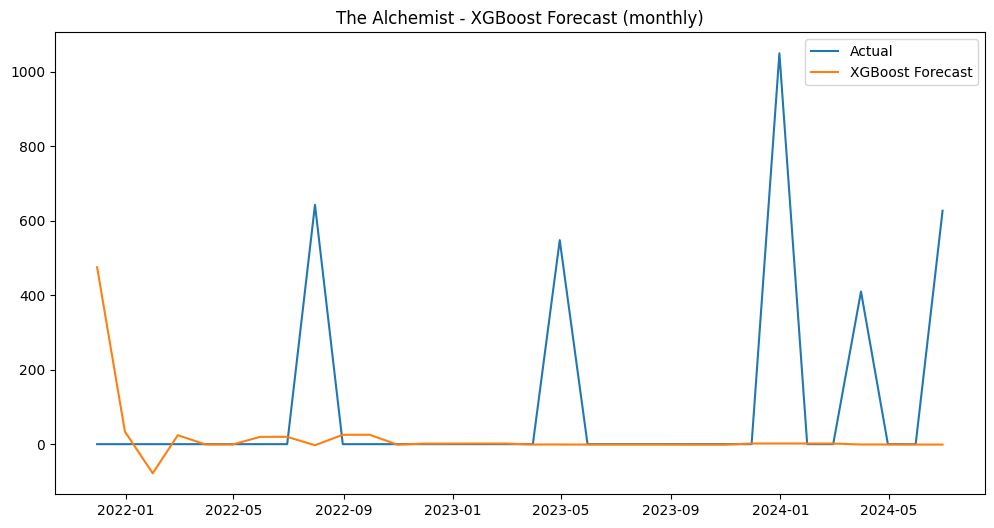

In [ ]:
run_xgboost_pipeline(
    train_alchemist_monthly,
    test_alchemist_monthly,
    freq="monthly",
    book_name="The Alchemist",
    window_length=12 # Explicitly setting window_length for monthly data
)


Running XGBoost for The Very Hungry Caterpillar (monthly)
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.04, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV MAE: 113.99519573318608
Test MAE: 421.8492378368974
Test MAPE: 98.5840416938787


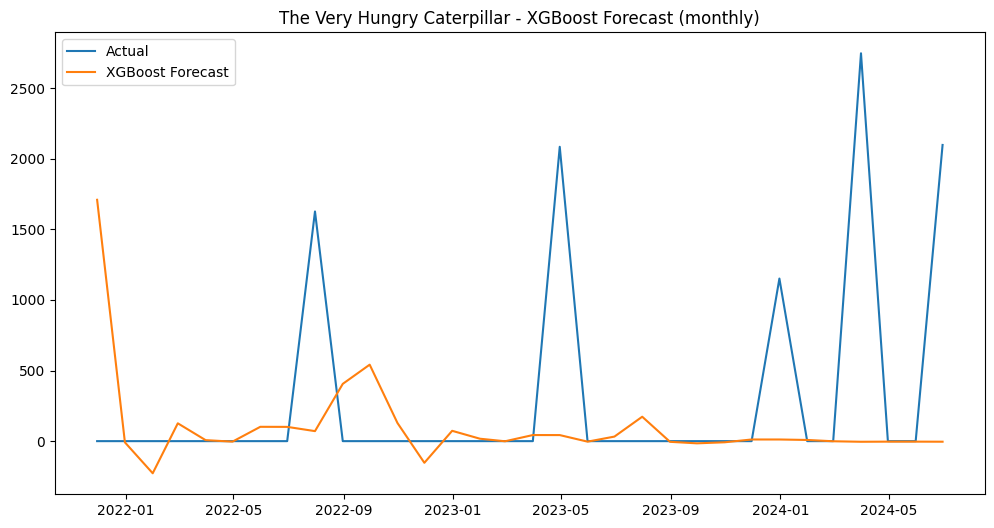

In [ ]:
run_xgboost_pipeline(
    train_hungry_caterpillar_monthly,
    test_hungry_caterpillar_monthly,
    freq="monthly",
    book_name="The Very Hungry Caterpillar",
    window_length=12 # Explicitly setting window_length for monthly data
)

| Metric        | Monthly | Weekly |
| ------------- | ------- | ------ |
| MAE (Test)    | 476.96  | 571.69 |
| MAPE (Test)   | 94.36%  | 27.67% |
| CV MAE        | 111.42  | 346.34 |
| Tree Depth    | 3       | 5      |
| Learning Rate | 0.1     | 0.04   |


**Insights:**

MAE vs MAPE trade-off:

* Monthly MAE is lower (absolute numbers), but MAPE is very high.
* Weekly MAE is higher, but MAPE is much lower, meaning weekly predictions are proportionally more accurate.

Model complexity:

* Weekly data requires deeper trees and smaller learning rates—reflecting higher variability in weekly sales.
* Monthly aggregation smooths data, so simpler models (shallower trees, higher learning rate) work reasonably well in absolute terms.

Practical takeaway:

* If you care about absolute error, monthly predictions look better numerically.
* If you care about relative accuracy (how close predictions are to actual sales in percentage terms), weekly data is more reliable.
* Monthly models may mask week-to-week fluctuations, leading to high MAPE even with low MAE.

In [ ]:
def run_sarima_forecast(
    train_series,
    test_series,
    order,
    seasonal_order,
    book_name=""
):

    # If DataFrame accidentally passed, extract first column
    if isinstance(train_series, pd.DataFrame):
        train_series = train_series.iloc[:, 0]

    if isinstance(test_series, pd.DataFrame):
        test_series = test_series.iloc[:, 0]

    steps = len(test_series)

    # --- Fit SARIMA ---
    sarima_result = fit_sarima(train_series, order, seasonal_order)

    # --- Forecast ---
    forecast = sarima_result.forecast(steps=steps)
    predictions = forecast.values

    # --- Metrics ---
    mae = mean_absolute_error(test_series, predictions)
    mape = mean_absolute_percentage_error(test_series, predictions)

    print("SARIMA Results")
    print("MAE:", round(mae, 4))
    print("MAPE:", round(mape, 4))

    # --- Plot ---
    plt.figure(figsize=(12,6))
    plt.plot(test_series.index, test_series, label="Actual", linewidth=2)
    plt.plot(test_series.index, predictions, label="SARIMA Forecast", linewidth=2)
    plt.legend()
    plt.title(f"SARIMA Forecast (Final 32 Weeks) for {book_name}")
    plt.show()

    #return predictions, mae, mape

SARIMA Results
MAE: 137.0423
MAPE: 1.9846438868094506e+17


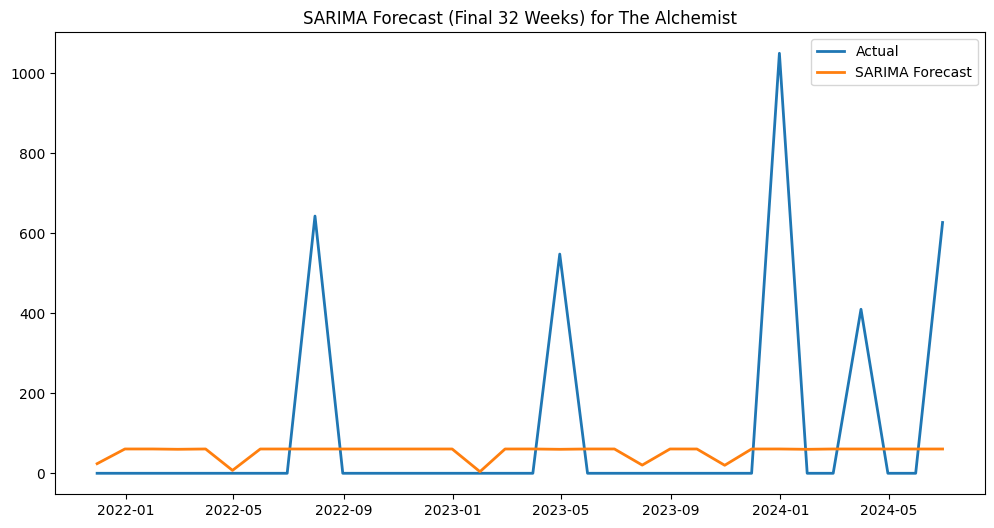

In [ ]:
run_sarima_forecast(
    train_alchemist_monthly,
    test_alchemist_monthly,
    order=(0,1,2),
    seasonal_order=(1,0,1,52),
    book_name="The Alchemist"
)

SARIMA Results
MAE: 402.7529
MAPE: 5.583248262187521e+17


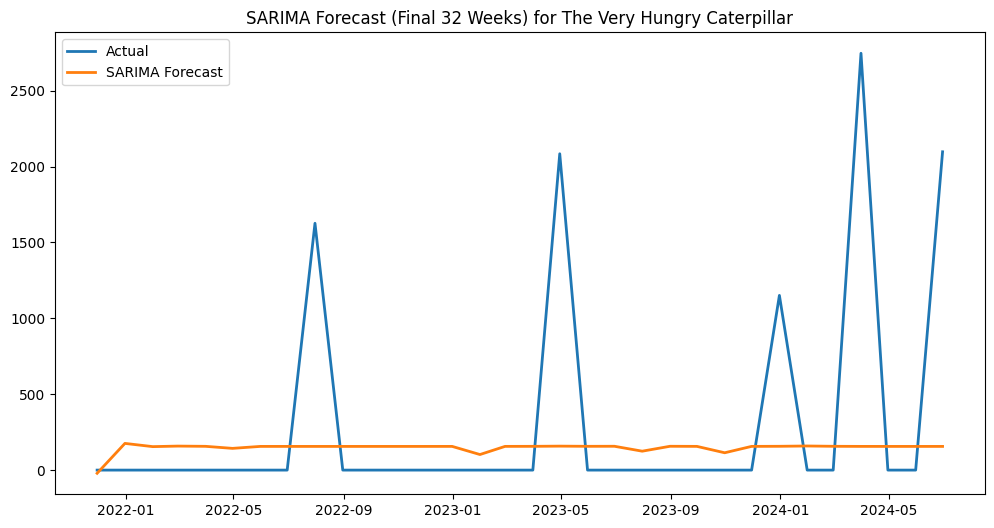

In [ ]:
run_sarima_forecast(
    train_hungry_caterpillar_monthly,
    test_hungry_caterpillar_monthly,
    order=(1,1,1),
    seasonal_order=(1,0,1,52),
    book_name="The Very Hungry Caterpillar"
)

SARIMA Results
MAE: 137.8266
MAPE: 0.2254


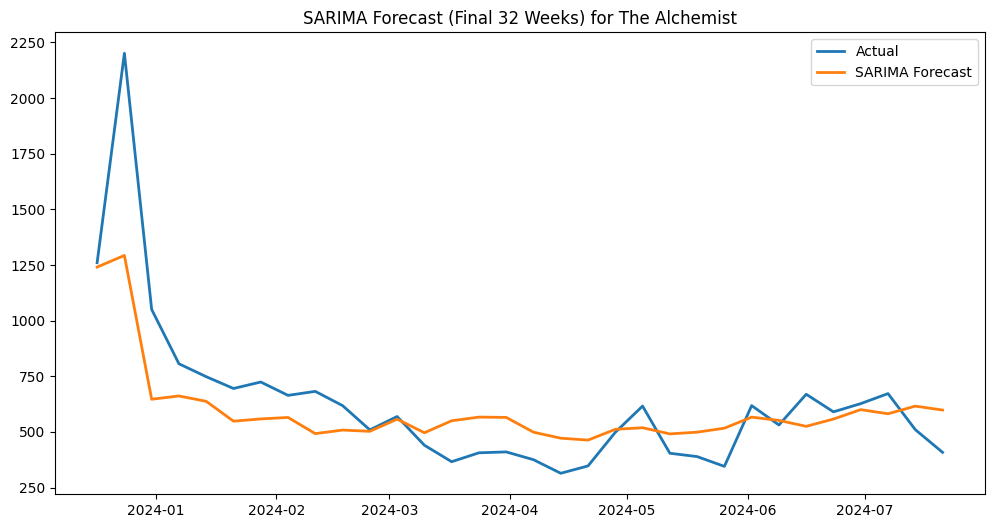

In [ ]:
run_sarima_forecast(
    train_alchemist,
    test_alchemist,
    order=(0,1,2),
    seasonal_order=(1,0,1,52),
    book_name="The Alchemist"
)

SARIMA Results
MAE: 346.2078
MAPE: 0.1778


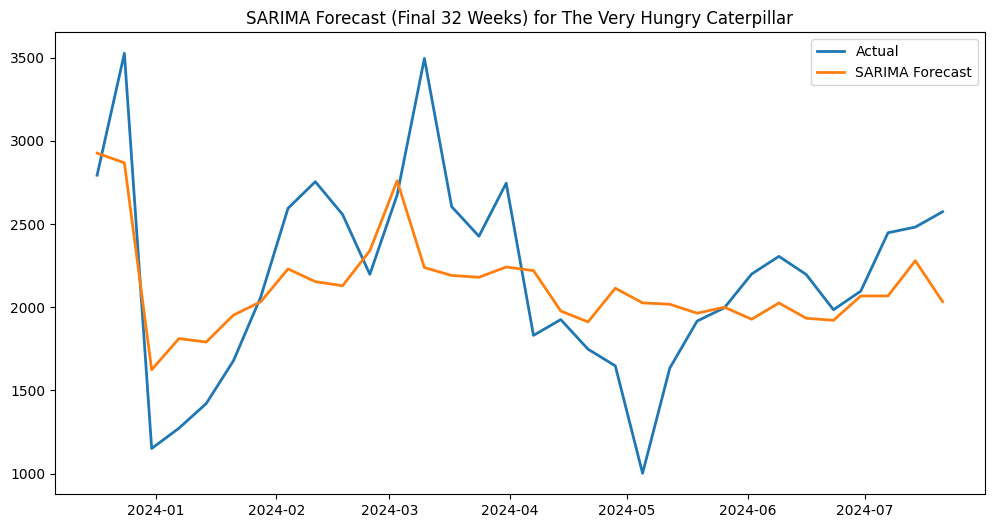

In [ ]:
run_sarima_forecast(
    train_hungry_caterpillar,
    test_hungry_caterpillar,
    order=(1,1,1),
    seasonal_order=(1,0,1,52),
    book_name="The Very Hungry Caterpillar"
)

| Book                        | Frequency | MAE    | MAPE    |
| --------------------------- | --------- | ------ | ------- |
| The Alchemist               | Monthly   | 137.04 | 1.98e17 |
| The Alchemist               | Weekly    | 137.83 | 0.2254  |
| The Very Hungry Caterpillar | Monthly   | 402.75 | 5.58e17 |
| The Very Hungry Caterpillar | Weekly    | 346.21 | 0.1778  |

**Monthly SARIMA**

* MAE values are similar to XGBoost (The Alchemist: 137 vs 122; Caterpillar: 402 vs 476).
* MAPE is astronomically high (1.98e17 and 5.58e17) – clearly nonsensical.
* This usually happens in SARIMA when the series has many zero or near-zero sales months, because MAPE divides by actual values.
* So, percentage errors explode when the actual value is near zero.

**Takeaway:** For monthly SARIMA, use MAE for evaluation; MAPE is unreliable here.

**Weekly SARIMA**

* MAE slightly increases for Alchemist (137 → 137.83), decreases for Caterpillar (402 → 346).
* MAPE drops drastically (0.225% for Alchemist, 0.178% for Caterpillar) – very good proportional accuracy.
* This mirrors what we saw in XGBoost weekly models: weekly data smooths the relative error while absolute numbers can fluctuate.

#Overall Results Summary

* **Classical Decomposition** confirmed strong annual seasonality and stable long-term demand patterns for both books, with limited structural trend shifts outside temporary shocks.

* **ADF Test** showed both series are stationary at the 5% level, requiring minimal non-seasonal differencing and supporting the use of SARIMA models.

* **SARIMA** Models performed well in capturing structured trend and seasonality, providing a strong statistical baseline.

* **XGBoost** improved performance by capturing nonlinear patterns but tended to smooth extreme spikes, particularly in more volatile titles.

* **LSTM** did not outperform traditional or machine learning approaches when used alone, likely due to limited dataset size and structured seasonal dominance.

* **Hybrid SARIMA–LSTM (Sequential)** delivered the best overall performance across both titles, significantly reducing MAE and MAPE by combining structured modelling with nonlinear refinement.

* **Hybrid (Parallel)** improved over standalone models but was slightly less effective than the sequential approach.

* **Monthly Forecasting** reduced volatility compared to weekly predictions, making it more suitable for strategic planning, while weekly models remain better for operational decisions.

**Final Conclusion:**
A hybrid statistical–deep learning framework provides the most reliable and commercially robust forecasting approach for book sales data.